# Predicting Adverse Birth Outcomes in Missouri Using County-Level Maternal Health Indicators, Social Determinants of Health, and Machine Learning

### HDS 5960 Capstone Project

Student: Lafouet Kevine Yemelong

Faculty Advisor: Prof. Brittany Hollister

Saint Louis University

Health Data Science Program

## Introduction

Adverse birth outcomes, including preterm birth and low birth weight, remain important public health concerns in Missouri and contribute substantially to maternal and infant morbidity, mortality, and healthcare costs. Identifying communities at increased risk may support targeted public health interventions and resource allocation.

This project integrates county-level birth outcome data from the Missouri Birth MICA database with socioeconomic indicators from the American Community Survey (ACS) and health indicators from County Health Rankings & Roadmaps. Machine learning and statistical models are used to identify predictors of adverse birth outcomes and compare predictive performance across multiple modeling approaches.

## Import Required Libraries

This section imports the Python libraries required for data manipulation, visualization, statistical analysis, spatial mapping, and machine learning.

In [2]:
# Importing libraries and defining paths

import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

BASE_PATH = Path(r"C:\Users\yemel\Downloads\Capstone dataset")

MICA_PATH = BASE_PATH / "Missouri Birth MICA Raw"
OUTPUT_PATH = BASE_PATH / "Processed Data"

OUTPUT_PATH.mkdir(exist_ok=True)

print("MICA folder exists:", MICA_PATH.exists())
print("Output folder exists:", OUTPUT_PATH.exists())

print("\nFiles in MICA folder:")
for file in MICA_PATH.iterdir():
    print(file.name)

MICA folder exists: True
Output folder exists: True

Files in MICA folder:
Early_Prenatal.csv
Education.csv
Live_Births.csv
Low_Birth_Weight.csv
Medicaid.csv
Preterm.csv
Smoking.csv


# Missouri Birth MICA Data Preparation

The Missouri Birth MICA dataset serves as the primary source of maternal and birth outcome information for this study. It includes county-level measures of live births, preterm birth, low birth weight, maternal smoking, prenatal care utilization, Medicaid-covered births, and maternal education.

The dataset was cleaned prior to integration with external datasets by selecting relevant variables, standardizing county names, verifying data types, and checking for missing values and duplicate records.

In [3]:
MICA_PATH = BASE_PATH / "Missouri Birth MICA Raw"

In [4]:
# Inspecting raw MICA dataset

test_file = MICA_PATH / "Live_Births.csv"

test_raw = pd.read_csv(
    test_file,
    header=None,
    engine="python",
    on_bad_lines="skip",
    dtype=str
)

print("Raw shape:", test_raw.shape)

display(test_raw.head(15))

Raw shape: (4, 3)


,0,1,2
0,Title:,Missouri Resident Births,NaN
1,Data selected in addition to rows and columns ...,Indicator: Live Births;,NaN
2,Source:,DHSS - MOPHIMS - Birth MICA,NaN
3,Generated On:,7/10/2026 8:45:12 PM,NaN


In [5]:
#Cleaning MICA CSV File

import csv
import pandas as pd
import numpy as np
from pathlib import Path


def clean_mica_file(file_path, value_name, statistic="Count"):
    """
    Clean a Missouri Birth MICA county-by-year CSV export.

    Parameters
    ----------
    file_path : str or Path
        Path to the MICA CSV file.

    value_name : str
        Name for the cleaned output variable.

    statistic : str
        Statistic to extract, usually "Count" or "Rate".

    Returns
    -------
    pandas.DataFrame
        Long-format county-year dataset.
    """

    file_path = Path(file_path)

    # will real all rows safely, even when metadata rows have
    # different numbers of columns
    with open(
        file_path,
        mode="r",
        encoding="utf-8-sig",
        errors="replace",
        newline=""
    ) as file:
        rows = list(csv.reader(file))

    # Locate the key rows
    year_row = None
    statistic_row = None
    county_header_row = None

    for i, row in enumerate(rows):

        first_cell = row[0].strip() if len(row) > 0 else ""

        if first_cell == "Year:":
            year_row = row

        elif first_cell == "Statistics:":
            statistic_row = row

        elif first_cell == "County":
            county_header_row = i
            break

    if year_row is None:
        raise ValueError(f"Year row not found in {file_path.name}")

    if statistic_row is None:
        raise ValueError(f"Statistics row not found in {file_path.name}")

    if county_header_row is None:
        raise ValueError(f"County header not found in {file_path.name}")

    # This builds a map of column position to year/statistic
    column_map = []

    max_length = max(len(year_row), len(statistic_row))

    for position in range(1, max_length):

        year = (
            year_row[position].strip()
            if position < len(year_row)
            else ""
        )

        stat = (
            statistic_row[position].strip()
            if position < len(statistic_row)
            else ""
        )

        # Retain only individual years 2016–2024
        if year.isdigit() and 2016 <= int(year) <= 2024:
            column_map.append({
                "position": position,
                "year": int(year),
                "statistic": stat
            })

    requested_statistic = statistic.strip().lower()

    selected_columns = [
        item for item in column_map
        if item["statistic"].strip().lower() == requested_statistic
    ]

    if not selected_columns:
        available = sorted({
            item["statistic"]
            for item in column_map
            if item["statistic"]
        })

        raise ValueError(
            f"No '{statistic}' columns found in {file_path.name}. "
            f"Available statistics: {available}"
        )

    # will extract county-year values
    records = []

   # Rows that are not counties
    excluded_counties = {
    "",
    "Missouri",
    "Missouri Total",
    "State Total",
    "Total",
    "Total for selection",
    "Total for Selection",
    "All Counties",
    "Unknown",
    "Unknown County",
    "Notes",
    "Note",
    "Source",
    "Source:",
    "Generated On",
    "Generated On:",
    "nan"
}
    for row in rows[county_header_row + 1:]:

        if not row:
            continue

        county = row[0].strip()

        if county in excluded_counties:
            continue

        for item in selected_columns:

            position = item["position"]

            value = (
                row[position].strip()
                if position < len(row)
                else ""
            )

            value = (
                value.replace(",", "")
                     .replace("%", "")
                     .replace("*", "")
                     .strip()
            )

            numeric_value = pd.to_numeric(
                value,
                errors="coerce"
            )

            records.append({
                "county": county,
                "year": item["year"],
                value_name: numeric_value
            })

    cleaned = pd.DataFrame(records)

    cleaned = cleaned.dropna(
        subset=["county", "year"]
    )

    cleaned = cleaned.sort_values(
        ["county", "year"]
    ).reset_index(drop=True)

    return cleaned

In [6]:
# Testing live births

live_births = clean_mica_file(
    MICA_PATH / "Live_Births.csv",
    value_name="live_births",
    statistic="Count"
)

print("Shape:", live_births.shape)
print("Counties:", live_births["county"].nunique())
print("Years:", sorted(live_births["year"].unique()))

display(live_births.head(20))

Shape: (1035, 3)
Counties: 115
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,county,year,live_births
0,Adair,2016,272
1,Adair,2017,266
2,Adair,2018,287
3,Adair,2019,301
4,Adair,2020,284
5,Adair,2021,266
6,Adair,2022,282
7,Adair,2023,283
8,Adair,2024,254
9,Andrew,2016,183


In [7]:
# Identify extra county labels
county_names = sorted(live_births["county"].dropna().unique())

print("Number of unique labels:", len(county_names))

for county in county_names:
    print(repr(county))

Number of unique labels: 115
'Adair'
'Andrew'
'Atchison'
'Audrain'
'Barry'
'Barton'
'Bates'
'Benton'
'Bollinger'
'Boone'
'Buchanan'
'Butler'
'Caldwell'
'Callaway'
'Camden'
'Cape Girardeau'
'Carroll'
'Carter'
'Cass'
'Cedar'
'Chariton'
'Christian'
'Clark'
'Clay'
'Clinton'
'Cole'
'Cooper'
'Crawford'
'Dade'
'Dallas'
'Daviess'
'DeKalb'
'Dent'
'Douglas'
'Dunklin'
'Franklin'
'Gasconade'
'Gentry'
'Greene'
'Grundy'
'Harrison'
'Henry'
'Hickory'
'Holt'
'Howard'
'Howell'
'Iron'
'Jackson'
'Jasper'
'Jefferson'
'Johnson'
'Knox'
'Laclede'
'Lafayette'
'Lawrence'
'Lewis'
'Lincoln'
'Linn'
'Livingston'
'Macon'
'Madison'
'Maries'
'Marion'
'McDonald'
'Mercer'
'Miller'
'Mississippi'
'Moniteau'
'Monroe'
'Montgomery'
'Morgan'
'New Madrid'
'Newton'
'Nodaway'
'Oregon'
'Osage'
'Ozark'
'Pemiscot'
'Perry'
'Pettis'
'Phelps'
'Pike'
'Platte'
'Polk'
'Pulaski'
'Putnam'
'Ralls'
'Randolph'
'Ray'
'Reynolds'
'Ripley'
'Saline'
'Schuyler'
'Scotland'
'Scott'
'Shannon'
'Shelby'
'St. Charles'
'St. Clair'
'St. Francois'
'St. Loui

In [8]:
live_births.groupby("county").size().sort_index().tail(15)

county
St. Louis City      9
St. Louis County    9
Ste. Genevieve      9
Stoddard            9
Stone               9
Sullivan            9
Taney               9
Texas               9
Vernon              9
Warren              9
Washington          9
Wayne               9
Webster             9
Worth               9
Wright              9
dtype: int64

In [9]:
# Cleaning all MICA indicator files

# Live births uses Count
live_births = clean_mica_file(
    MICA_PATH / "Live_Births.csv",
    value_name="live_births",
    statistic="Count"
)

# All outcome and predictor indicators use Rate
preterm = clean_mica_file(
    MICA_PATH / "Preterm.csv",
    value_name="preterm_rate",
    statistic="Rate"
)

lbw = clean_mica_file(
    MICA_PATH / "Low_Birth_Weight.csv",
    value_name="lbw_rate",
    statistic="Rate"
)

smoking = clean_mica_file(
    MICA_PATH / "Smoking.csv",
    value_name="smoking_rate",
    statistic="Rate"
)

early_prenatal = clean_mica_file(
    MICA_PATH / "Early_Prenatal.csv",
    value_name="early_prenatal_rate",
    statistic="Rate"
)

medicaid = clean_mica_file(
    MICA_PATH / "Medicaid.csv",
    value_name="medicaid_rate",
    statistic="Rate"
)

education = clean_mica_file(
    MICA_PATH / "Education.csv",
    value_name="low_education_rate",
    statistic="Rate"
)

mica_datasets = {
    "Live Births": live_births,
    "Preterm": preterm,
    "Low Birth Weight": lbw,
    "Smoking": smoking,
    "Early Prenatal": early_prenatal,
    "Medicaid": medicaid,
    "Education": education
}

for name, df in mica_datasets.items():
    print(
        f"{name}: "
        f"shape={df.shape}, "
        f"counties={df['county'].nunique()}, "
        f"years={df['year'].nunique()}"
    )

Live Births: shape=(1035, 3), counties=115, years=9
Preterm: shape=(1062, 3), counties=118, years=9
Low Birth Weight: shape=(1062, 3), counties=118, years=9
Smoking: shape=(1062, 3), counties=118, years=9
Early Prenatal: shape=(1053, 3), counties=117, years=9
Medicaid: shape=(1062, 3), counties=118, years=9
Education: shape=(1062, 3), counties=118, years=9


In [10]:
# Filter all indicator files to the 115 valid counties
valid_counties = set(live_births["county"].unique())

def keep_valid_counties(df, valid_counties):
    """
    Keep only the 115 verified Missouri counties from Live Births.
    """
    return (
        df[df["county"].isin(valid_counties)]
        .drop_duplicates(subset=["county", "year"])
        .sort_values(["county", "year"])
        .reset_index(drop=True)
    )

preterm = keep_valid_counties(preterm, valid_counties)
lbw = keep_valid_counties(lbw, valid_counties)
smoking = keep_valid_counties(smoking, valid_counties)
early_prenatal = keep_valid_counties(early_prenatal, valid_counties)
medicaid = keep_valid_counties(medicaid, valid_counties)
education = keep_valid_counties(education, valid_counties)

In [11]:
# Verify cleaned MICA files 
mica_datasets = {
    "Live Births": live_births,
    "Preterm": preterm,
    "Low Birth Weight": lbw,
    "Smoking": smoking,
    "Early Prenatal": early_prenatal,
    "Medicaid": medicaid,
    "Education": education
}

for name, df in mica_datasets.items():
    print(
        f"{name}: "
        f"shape={df.shape}, "
        f"counties={df['county'].nunique()}, "
        f"years={df['year'].nunique()}, "
        f"duplicates={df.duplicated(['county', 'year']).sum()}"
    )

Live Births: shape=(1035, 3), counties=115, years=9, duplicates=0
Preterm: shape=(1035, 3), counties=115, years=9, duplicates=0
Low Birth Weight: shape=(1035, 3), counties=115, years=9, duplicates=0
Smoking: shape=(1035, 3), counties=115, years=9, duplicates=0
Early Prenatal: shape=(1035, 3), counties=115, years=9, duplicates=0
Medicaid: shape=(1035, 3), counties=115, years=9, duplicates=0
Education: shape=(1035, 3), counties=115, years=9, duplicates=0


In [12]:
# Merge all clean MICA indicators
mica_master = live_births.copy()

for df in [
    preterm,
    lbw,
    smoking,
    early_prenatal,
    medicaid,
    education
]:
    mica_master = mica_master.merge(
        df,
        on=["county", "year"],
        how="left",
        validate="one_to_one"
    )

mica_master = (
    mica_master
    .sort_values(["county", "year"])
    .reset_index(drop=True)
)

print("MICA master shape:", mica_master.shape)
print("Counties:", mica_master["county"].nunique())
print("Years:", mica_master["year"].nunique())

display(mica_master.head(20))

MICA master shape: (1035, 9)
Counties: 115
Years: 9


,county,year,live_births,preterm_rate,lbw_rate,smoking_rate,early_prenatal_rate,medicaid_rate,low_education_rate
0,Adair,2016,272,12.87,8.09,13.33,78.07,31.73,17.04
1,Adair,2017,266,9.77,9.77,16.03,75.95,27.82,12.88
2,Adair,2018,287,8.36,7.67,16.43,74.91,32.40,14.34
3,Adair,2019,301,13.62,10.63,15.05,77.26,30.56,11.71
4,Adair,2020,284,11.27,7.04,12.72,74.55,34.15,18.31
5,Adair,2021,266,10.15,9.02,12.40,75.57,38.35,12.83
6,Adair,2022,282,8.87,6.74,10.75,73.84,50.00,12.41
7,Adair,2023,283,9.19,8.16,11.66,67.74,41.70,13.07
8,Adair,2024,254,11.07,9.06,9.84,74.40,52.36,12.65
9,Andrew,2016,183,12.02,9.29,14.21,84.70,25.27,NaN


In [13]:
# Checking missing values and variable ranges 
missing_summary = pd.DataFrame({
    "Missing_Count": mica_master.isna().sum(),
    "Missing_Percent": (mica_master.isna().mean() * 100).round(2)
})

display(missing_summary)

display(
    mica_master[
        [
            "live_births",
            "preterm_rate",
            "lbw_rate",
            "smoking_rate",
            "early_prenatal_rate",
            "medicaid_rate",
            "low_education_rate"
        ]
    ].describe().T
)

,Missing_Count,Missing_Percent
county,0,0.00
year,0,0.00
live_births,0,0.00
preterm_rate,180,17.39
lbw_rate,252,24.35
smoking_rate,117,11.30
early_prenatal_rate,0,0.00
medicaid_rate,27,2.61
low_education_rate,90,8.70


,count,mean,std,min,25%,50%,75%,max
live_births,1035.0,614.002899,1422.372223,16.00,107.500,215.000,464.5000,11673.00
preterm_rate,855.0,10.693789,2.467388,4.35,8.990,10.540,12.2400,25.00
lbw_rate,783.0,8.381226,2.191180,2.54,6.885,8.120,9.5750,16.24
smoking_rate,918.0,15.895011,6.875165,1.25,10.415,15.735,20.6675,38.78
early_prenatal_rate,1035.0,72.339275,7.547717,30.95,67.725,72.990,77.5100,93.75
medicaid_rate,1008.0,43.228026,13.304214,12.50,32.680,42.505,52.0650,81.25
low_education_rate,945.0,16.880148,9.559776,3.01,10.740,14.930,19.7500,74.07


In [14]:
mica_master.to_csv(
    OUTPUT_PATH / "mica_clean.csv",
    index=False
)

print("MICA dataset saved.")

MICA dataset saved.


# American Community Survey (ACS) Data Preparation

The American Community Survey (ACS) dataset provides county-level socioeconomic characteristics used as predictors in the machine learning models. Variables include population, median household income, unemployment, poverty, educational attainment, and health insurance coverage.

The ACS dataset was cleaned independently to ensure consistent county identifiers and compatible variable formats before merging with the Missouri Birth MICA dataset.

In [15]:
ACS_PATH = Path(r"C:\Users\yemel\Downloads\Capstone dataset\ACS datasets Raw")

In [16]:
# Loading ACS Datasets

from pathlib import Path
import pandas as pd

ACS_PATH = Path(r"C:\Users\yemel\Downloads\Capstone dataset\ACS datasets Raw")

acs_income = pd.read_csv(ACS_PATH / "ACS_Income_Employment.csv")
acs_demo = pd.read_csv(ACS_PATH / "ACS_Demographics.csv")
acs_education = pd.read_csv(ACS_PATH / "ACS_Education.csv")
acs_poverty = pd.read_csv(ACS_PATH / "ACS_Poverty.csv")
acs_insurance = pd.read_csv(ACS_PATH / "ACS_Insurance.csv")

In [17]:
# Verify loaded files
print("Income:", acs_income.shape)
print("Demographics:", acs_demo.shape)
print("Education:", acs_education.shape)
print("Poverty:", acs_poverty.shape)
print("Insurance:", acs_insurance.shape)

Income: (145, 465)
Demographics: (99, 465)
Education: (117, 771)
Poverty: (69, 697)
Insurance: (117, 612)


In [18]:
# Clean ACS label column 

for df in [acs_income, acs_demo, acs_poverty]:
    df["label_clean"] = (
        df["Label (Grouping)"]
        .astype(str)
        .str.replace("\xa0", " ", regex=False)
        .str.strip()
    )

In [19]:
# Helper function to clean ACS values
import pandas as pd
import numpy as np

def clean_number(value):
    """
    Convert ACS values to numeric.
    Handles commas, dollar signs, percentages, and missing values.
    """

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Removing formatting characters
    value = (
        value.replace(",", "")
             .replace("$", "")
             .replace("%", "")
    )

    # Treat these as missing
    if value in ["", "-", "(X)", "N", "null"]:
        return np.nan

    try:
        return float(value)
    except ValueError:
        return np.nan

In [20]:
# Select ACS rows needed for analysis 

population_row = acs_demo[
    acs_demo["label_clean"] == "Total population"
].iloc[0]

income_row = acs_income[
    acs_income["label_clean"] == "Median household income (dollars)"
].iloc[0]

unemployment_row = acs_income[
    acs_income["label_clean"] == "Unemployment Rate"
].iloc[0]

poverty_row = acs_poverty[
    acs_poverty["label_clean"] == "Population for whom poverty status is determined"
].iloc[0]

print("Rows selected successfully")

Rows selected successfully


In [21]:
# Creating a clean ACS dataset
rows = []

for col in acs_demo.columns:

    if col.endswith("County, Missouri!!Estimate") or col.endswith("city, Missouri!!Estimate"):

        county = col.split("!!")[0].replace(", Missouri", "")

        population = clean_number(population_row[col])
        median_income = clean_number(income_row[col])

        unemployment_col = col.replace("Estimate", "Percent")
        unemployment_rate = clean_number(unemployment_row[unemployment_col])

        poverty_col = col.replace(
            "!!Estimate",
            "!!Percent below poverty level!!Estimate"
        )
        poverty_rate = clean_number(poverty_row[poverty_col])

        rows.append([
            county,
            population,
            median_income,
            unemployment_rate,
            poverty_rate
        ])

acs_clean = pd.DataFrame(
    rows,
    columns=[
        "county",
        "population",
        "median_income",
        "unemployment_rate",
        "poverty_rate"
    ]
)

print(acs_clean.shape)
acs_clean.head()

(115, 5)


,county,population,median_income,unemployment_rate,poverty_rate
0,Adair County,25224.0,56583.0,4.9,21.2
1,Andrew County,18086.0,74007.0,4.0,7.4
2,Atchison County,5216.0,59260.0,2.3,12.5
3,Audrain County,24688.0,56232.0,4.1,18.0
4,Barry County,34831.0,56611.0,4.1,16.7


In [22]:
# Save clean ACS dataset

acs_clean.to_csv(
    OUTPUT_PATH / "missouri_acs_clean.csv",
    index=False
)

print("ACS clean dataset saved successfully.")
print(acs_clean.shape)

ACS clean dataset saved successfully.
(115, 5)


In [23]:
# Adding education and insurance to ACS

# Remove description row

education_clean = acs_education.iloc[1:].copy()
insurance_clean = acs_insurance.iloc[1:].copy()

# Keep needed columns

education_clean = education_clean[
    ["NAME", "S1501_C02_015E"]
]

insurance_clean = insurance_clean[
    ["NAME", "S2701_C05_001E"]
]

# Rename columns

education_clean.columns = [
    "county",
    "bachelors_plus_rate"
]

insurance_clean.columns = [
    "county",
    "uninsured_rate"
]

# Remove Missouri statewide row

education_clean = education_clean[
    education_clean["county"] != "Missouri"
]

insurance_clean = insurance_clean[
    insurance_clean["county"] != "Missouri"
]

# Remove ", Missouri"

education_clean["county"] = (
    education_clean["county"]
    .str.replace(", Missouri", "", regex=False)
)

insurance_clean["county"] = (
    insurance_clean["county"]
    .str.replace(", Missouri", "", regex=False)
)

# Convert to numeric

education_clean["bachelors_plus_rate"] = pd.to_numeric(
    education_clean["bachelors_plus_rate"],
    errors="coerce"
)

insurance_clean["uninsured_rate"] = pd.to_numeric(
    insurance_clean["uninsured_rate"],
    errors="coerce"
)

print(education_clean.shape)
print(insurance_clean.shape)

education_clean.head()

(115, 2)
(115, 2)


,county,bachelors_plus_rate
2,Adair County,35.0
3,Andrew County,26.9
4,Atchison County,22.0
5,Audrain County,16.1
6,Barry County,13.4


In [24]:
# Merge education + Insurance

acs_clean = acs_clean.merge(
    education_clean,
    on="county",
    how="left"
)

acs_clean = acs_clean.merge(
    insurance_clean,
    on="county",
    how="left"
)

print(acs_clean.shape)

acs_clean.head()

(115, 7)


,county,population,median_income,unemployment_rate,poverty_rate,bachelors_plus_rate,uninsured_rate
0,Adair County,25224.0,56583.0,4.9,21.2,35.0,8.2
1,Andrew County,18086.0,74007.0,4.0,7.4,26.9,6.0
2,Atchison County,5216.0,59260.0,2.3,12.5,22.0,12.0
3,Audrain County,24688.0,56232.0,4.1,18.0,16.1,14.5
4,Barry County,34831.0,56611.0,4.1,16.7,13.4,12.9


In [25]:
# Save clean ACS dataset

acs_clean.to_csv(
    OUTPUT_PATH / "acs_clean.csv",
    index=False
)

print("ACS dataset saved.")
print(acs_clean.shape)

ACS dataset saved.
(115, 7)


In [26]:
# Standardising ACS county names
acs_clean["county"] = (
    acs_clean["county"]
    .str.replace(" County", "", regex=False)
    .str.strip()
)

print(acs_clean.head())
print("\nNumber of counties:", acs_clean["county"].nunique())

     county  population  median_income  unemployment_rate  poverty_rate  \
0     Adair     25224.0        56583.0                4.9          21.2   
1    Andrew     18086.0        74007.0                4.0           7.4   
2  Atchison      5216.0        59260.0                2.3          12.5   
3   Audrain     24688.0        56232.0                4.1          18.0   
4     Barry     34831.0        56611.0                4.1          16.7   

   bachelors_plus_rate  uninsured_rate  
0                 35.0             8.2  
1                 26.9             6.0  
2                 22.0            12.0  
3                 16.1            14.5  
4                 13.4            12.9  

Number of counties: 115


In [27]:
# Fixing st louis county names in ACS
acs_clean["county"] = acs_clean["county"].replace({
    "St. Louis": "St. Louis County",
    "St. Louis city": "St. Louis City"
})

print(sorted(acs_clean["county"].unique())[-10:])

['Sullivan', 'Taney', 'Texas', 'Vernon', 'Warren', 'Washington', 'Wayne', 'Webster', 'Worth', 'Wright']


In [28]:
# Comparing MICA and ACS counties
mica_counties = set(mica_master["county"].unique())
acs_counties = set(acs_clean["county"].unique())

print("Counties only in MICA")
print(sorted(mica_counties - acs_counties))

print("\nCounties only in ACS")
print(sorted(acs_counties - mica_counties))

Counties only in MICA
[]

Counties only in ACS
[]


# Integrating Missouri Birth MICA and ACS Data

Following independent cleaning, the Missouri Birth MICA and ACS datasets were merged using county and year identifiers. After merging, quality assurance checks were performed to verify the number of observations, identify unmatched counties, assess missing values, and confirm that each county-year combination remained unique.

In [29]:
# Merging MICA + ACS
mica_acs = mica_master.merge(
    acs_clean,
    on="county",
    how="left",
    validate="many_to_one"
)

print("Merged MICA + ACS shape:", mica_acs.shape)

print("\nMissing ACS values after merge:")
display(
    mica_acs[
        [
            "population",
            "median_income",
            "unemployment_rate",
            "poverty_rate",
            "bachelors_plus_rate",
            "uninsured_rate"
        ]
    ].isna().sum().to_frame("Missing_Count")
)

display(mica_acs.head())

Merged MICA + ACS shape: (1035, 15)

Missing ACS values after merge:


,Missing_Count
population,0
median_income,0
unemployment_rate,0
poverty_rate,0
bachelors_plus_rate,0
uninsured_rate,0


,county,year,live_births,preterm_rate,lbw_rate,smoking_rate,early_prenatal_rate,medicaid_rate,low_education_rate,population,median_income,unemployment_rate,poverty_rate,bachelors_plus_rate,uninsured_rate
0,Adair,2016,272,12.87,8.09,13.33,78.07,31.73,17.04,25224.0,56583.0,4.9,21.2,35.0,8.2
1,Adair,2017,266,9.77,9.77,16.03,75.95,27.82,12.88,25224.0,56583.0,4.9,21.2,35.0,8.2
2,Adair,2018,287,8.36,7.67,16.43,74.91,32.40,14.34,25224.0,56583.0,4.9,21.2,35.0,8.2
3,Adair,2019,301,13.62,10.63,15.05,77.26,30.56,11.71,25224.0,56583.0,4.9,21.2,35.0,8.2
4,Adair,2020,284,11.27,7.04,12.72,74.55,34.15,18.31,25224.0,56583.0,4.9,21.2,35.0,8.2


In [30]:
# Saving MICA + ACS DATASET
mica_acs.to_csv(
    OUTPUT_PATH / "mica_acs_merged.csv",
    index=False
)

print("MICA + ACS dataset saved.")

MICA + ACS dataset saved.


# County Health Rankings Data Preparation

The County Health Rankings & Roadmaps dataset provides additional county-level indicators describing health behaviors, healthcare access, and community health characteristics. Variables selected for this study include adult smoking, adult obesity, physical inactivity, food environment index, primary care physician ratio, childhood poverty, unemployment, and uninsured rates.

The dataset was cleaned independently before integration with the existing analytical dataset.

In [31]:
# Loading COUNTY HEALTH RANKINGS DATA
CHR_PATH = Path(r"C:\Users\yemel\Downloads\Capstone dataset\Health Rankings Raw")

print("Files in CHR folder:")
for file in CHR_PATH.iterdir():
    print(file.name)

Files in CHR folder:
Ranked measure data.csv


In [32]:
# READ CHR DATA

chr_file = CHR_PATH / "Ranked measure data.csv"

chr_raw = pd.read_csv(chr_file)

chr_raw.columns = chr_raw.columns.str.strip()

print("CHR shape:", chr_raw.shape)
print(chr_raw.columns.tolist()[:50])

display(chr_raw.head())

CHR shape: (117, 246)
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Premature Death', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Poor or Fair Health', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Poor Physical Health Days', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Poor Mental Health Days', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Low Birthweight', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Premature Death,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Poor or Fair Health,Unnamed: 30,Unnamed: 31,Unnamed: 32,Poor Physical Health Days,Unnamed: 34,Unnamed: 35,Unnamed: 36,Poor Mental Health Days,Unnamed: 38,Unnamed: 39,Unnamed: 40,Low Birthweight,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Adult Smoking,Unnamed: 62,Unnamed: 63,Unnamed: 64,Adult Obesity,Unnamed: 66,Unnamed: 67,Unnamed: 68,Food Environment Index,Unnamed: 70,Physical Inactivity,Unnamed: 72,Unnamed: 73,Unnamed: 74,Access to Exercise Opportunities,Unnamed: 76,Excessive Drinking,Unnamed: 78,Unnamed: 79,Unnamed: 80,Alcohol-Impaired Driving Deaths,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85,Unnamed: 86,Sexually Transmitted Infections,Unnamed: 88,Unnamed: 89,Teen Births,Unnamed: 91,Unnamed: 92,Unnamed: 93,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,Unnamed: 104,Unnamed: 105,Unnamed: 106,Unnamed: 107,Unnamed: 108,Uninsured,Unnamed: 110,Unnamed: 111,Unnamed: 112,Unnamed: 113,Primary Care Physicians,Unnamed: 115,Unnamed: 116,Unnamed: 117,Dentists,Unnamed: 119,Unnamed: 120,Unnamed: 121,Mental Health Providers,Unnamed: 123,Unnamed: 124,Unnamed: 125,Preventable Hospital Stays,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,Unnamed: 131,Unnamed: 132,Mammography Screening,Unnamed: 134,Unnamed: 135,Unnamed: 136,Unnamed: 137,Unnamed: 138,Unnamed: 139,Flu Vaccinations,Unnamed: 141,Unnamed: 142,Unnamed: 143,Unnamed: 144,Unnamed: 145,Unnamed: 146,High School Completion,Unnamed: 148,Unnamed: 149,Unnamed: 150,Unnamed: 151,Unnamed: 152,Some College,Unnamed: 154,Unnamed: 155,Unnamed: 156,Unnamed: 157,Unnamed: 158,Unemployment,Unnamed: 160,Unnamed: 161,Unnamed: 162,Children in Poverty,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171,Income Inequality,Unnamed: 173,Unnamed: 174,Unnamed: 175,Children in Single-Parent Households,Unnamed: 177,Unnamed: 178,Unnamed: 179,Unnamed: 180,Unnamed: 181,Social Associations,Unnamed: 183,Unnamed: 184,Injury Deaths,Unnamed: 186,Unnamed: 187,Unnamed: 188,Unnamed: 189,Unnamed: 190,Unnamed: 191,Unnamed: 192,Unnamed: 193,Unnamed: 194,Unnamed: 195,Unnamed: 196,Unnamed: 197,Unnamed: 198,Unnamed: 199,Unnamed: 200,Unnamed: 201,Unnamed: 202,Unnamed: 203,Unnamed: 204,Air Pollution - Particulate Matter,Unnamed: 206,Drinking Water Violations,Unnamed: 208,Severe Housing Problems,Unnamed: 210,Unnamed: 211,Unnamed: 212,Unnamed: 213,Unnamed: 214,Unnamed: 215,Unnamed: 216,Unnamed: 217,Unnamed: 218,Unnamed: 219,Unnamed: 220,Unnamed: 221,Driving Alone to Work,Unnamed: 223,Unnamed: 224,Unnamed: 225,Unnamed: 226,Unnamed: 227,Unnamed: 228,Unnamed: 229,Unnamed: 230,Unnamed: 231,Unnamed: 232,Unnamed: 233,Unnamed: 234,Unnamed: 235,Unnamed: 236,Unnamed: 237,Unnamed: 238,Unnamed: 239,Unnamed: 240,Long Commute - Driving Alone,Unnamed: 242,Unnamed: 243,Unnamed: 244,Unnamed: 245
0,FIPS,State,County,Unreliable,Deaths,Years of Potential Life Lost Rate,95% CI - Low,95% CI - High,Z-Score,YPLL Rate (AIAN),YPLL Rate (AIAN) 95% CI - Low,YPLL Rate (AIAN) 95% CI - High,YPLL Rate (AIAN) Unreliable,YPLL Rate (Asian),YPLL Rate (Asian) 95% CI - Low,YPLL Rate (Asian) 95% CI - High,YPLL Rate (Asian) Unreliable,YPLL Rate (Black),YPLL Rate (Black) 95% CI - Low,YPLL Rate (Black) 95% CI - High,YPLL Rate (Black) Unreliable,YPLL Rate (Hispanic),YPLL Rate (Hispanic) 95% CI - Low,YPLL Rate (Hispanic) 95% CI - High,YPLL Rate (Hispanic) Unreliable,YPLL Rate (White),YPLL Rate (White) 95% CI - Low,YPLL R

In [33]:
# FIX CHR HEADERS
# Use first row as the real column names
chr_fixed = chr_raw.copy()

chr_fixed.columns = chr_fixed.iloc[0]

# Remove the first row because it is now the header
chr_fixed = chr_fixed.iloc[1:].copy()

# Clean column names
chr_fixed.columns = chr_fixed.columns.astype(str).str.strip()

print("Fixed CHR shape:", chr_fixed.shape)
print(chr_fixed.columns.tolist()[:40])

display(chr_fixed.head())

Fixed CHR shape: (116, 246)
['FIPS', 'State', 'County', 'Unreliable', 'Deaths', 'Years of Potential Life Lost Rate', '95% CI - Low', '95% CI - High', 'Z-Score', 'YPLL Rate (AIAN)', 'YPLL Rate (AIAN) 95% CI - Low', 'YPLL Rate (AIAN) 95% CI - High', 'YPLL Rate (AIAN) Unreliable', 'YPLL Rate (Asian)', 'YPLL Rate (Asian) 95% CI - Low', 'YPLL Rate (Asian) 95% CI - High', 'YPLL Rate (Asian) Unreliable', 'YPLL Rate (Black)', 'YPLL Rate (Black) 95% CI - Low', 'YPLL Rate (Black) 95% CI - High', 'YPLL Rate (Black) Unreliable', 'YPLL Rate (Hispanic)', 'YPLL Rate (Hispanic) 95% CI - Low', 'YPLL Rate (Hispanic) 95% CI - High', 'YPLL Rate (Hispanic) Unreliable', 'YPLL Rate (White)', 'YPLL Rate (White) 95% CI - Low', 'YPLL Rate (White) 95% CI - High', 'YPLL Rate (White) Unreliable', '% Fair or Poor Health', '95% CI - Low', '95% CI - High', 'Z-Score', 'Average Number of Physically Unhealthy Days', '95% CI - Low', '95% CI - High', 'Z-Score', 'Average Number of Mentally Unhealthy Days', '95% CI - Low', 

,FIPS,State,County,Unreliable,Deaths,Years of Potential Life Lost Rate,95% CI - Low,95% CI - High,Z-Score,YPLL Rate (AIAN),YPLL Rate (AIAN) 95% CI - Low,YPLL Rate (AIAN) 95% CI - High,YPLL Rate (AIAN) Unreliable,YPLL Rate (Asian),YPLL Rate (Asian) 95% CI - Low,YPLL Rate (Asian) 95% CI - High,YPLL Rate (Asian) Unreliable,YPLL Rate (Black),YPLL Rate (Black) 95% CI - Low,YPLL Rate (Black) 95% CI - High,YPLL Rate (Black) Unreliable,YPLL Rate (Hispanic),YPLL Rate (Hispanic) 95% CI - Low,YPLL Rate (Hispanic) 95% CI - High,YPLL Rate (Hispanic) Unreliable,YPLL Rate (White),YPLL Rate (White) 95% CI - Low,YPLL Rate (White) 95% CI - High,YPLL Rate (White) Unreliable,% Fair or Poor Health,95% CI - Low,95% CI - High,Z-Score,Average Number of Physically Unhealthy Days,95% CI - Low,95% CI - High,Z-Score,Average Number of Mentally Unhealthy Days,95% CI - Low,95% CI - High,Z-Score,Unreliable,% Low Birthweight,95% CI - Low,95% CI - High,Z-Score,% LBW (AIAN),% LBW (AIAN) 95% CI - Low,% LBW (AIAN) 95% CI - High,% LBW (Asian),% LBW (Asian) 95% CI - Low,% LBW (Asian) 95% CI - High,% LBW (Black),% LBW (Black) 95% CI - Low,% LBW (Black) 95% CI - High,% LBW (Hispanic),% LBW (Hispanic) 95% CI - Low,% LBW (Hispanic) 95% CI - High,% LBW (White),% LBW (White) 95% CI - Low,% LBW (White) 95% CI - High,% Adults Reporting Currently Smoking,95% CI - Low,95% CI - High,Z-Score,% Adults with Obesity,95% CI - Low,95% CI - High,Z-Score,Food Environment Index,Z-Score,% Physically Inactive,95% CI - Low,95% CI - High,Z-Score,% With Access to Exercise Opportunities,Z-Score,% Excessive Drinking,95% CI - Low,95% CI - High,Z-Score,# Alcohol-Impaired Driving Deaths,# Driving Deaths,% Driving Deaths with Alcohol Involvement,95% CI - Low,95% CI - High,Z-Score,# Chlamydia Cases,Chlamydia Rate,Z-Score,Teen Birth Rate,95% CI - Low,95% CI - High,Z-Score,Teen Birth Rate (AIAN),Teen Birth Rate (AIAN) 95% CI - Low,Teen Birth Rate (AIAN) 95% CI - High,Teen Birth Rate (Asian),Teen Birth Rate (Asian) 95% CI - Low,Teen Birth Rate (Asian) 95% CI - High,Teen Birth Rate (Black),Teen Birth Rate (Black) 95% CI - Low,Teen Birth Rate (Black) 95% CI - High,Teen Birth Rate (Hispanic),Teen Birth Rate (Hispanic) 95% CI - Low,Teen Birth Rate (Hispanic) 95% CI - High,Teen Birth Rate (White),Teen Birth Rate (White) 95% CI - Low,Teen Birth Rate (White) 95% CI - High,# Uninsured,% Uninsured,95% CI - Low,95% CI - High,Z-Score,# Primary Care Physicians,Primary Care Physicians Rate,Primary Care Physicians Ratio,Z-Score,# Dentists,Dentist Rate,Dentist Ratio,Z-Score,# Mental Health Providers,Mental Health Provider Rate,Mental Health Provider Ratio,Z-Score,Preventable Hospitalization Rate,Z-Score,Preventable Hosp. Rate (AIAN),Preventable Hosp. Rate (Asian),Preventable Hosp. Rate (Black),Preventable Hosp. Rate (Hispanic),Preventable Hosp. Rate (White),% with Annual Mammogram,Z-Score,% Screened (AIAN),% Screened (Asian),% Screened (Black),% Screened (Hispanic),% Screened (White),% Vaccinated,Z-Score,% Vaccinated (AIAN),% Vaccinated (Asian),% Vaccinated (Black),% Vaccinated (Hispanic),% Vaccinated (White),# Completed High School,Population,% Completed High School,95% CI - Low,95% CI - High,Z-Score,# Some College,Population,% Some College,95% CI - Low,95% CI - High,Z-Score,# Unemployed,Labor Force,% Unemployed,Z-Score,% Children in Poverty,95% CI - Low,95% CI - High,Z-Score,% Children in Poverty (AIAN),% Children in Poverty (Asian),% Children in Poverty (Black),% Children in Poverty (Hispanic),% Children in Poverty (White),80th Percentile Income,20th Percentile Income,Income Ratio,Z-Score,# Children in Single-Parent Households,# Children in Households,% Children in Single-Parent Households,95% CI - Low,95% CI - High,Z-Score,# Associations,Social Association Rate,Z-Score,# Injury Deaths,Injury Death Rate,95% CI - Low,95% CI - High,Z-Score,Injury Death Rate (AIAN),Injury Death Rate (AIAN) 95% CI - Low,Injury Death Rate (AIAN) 95% CI - High,Injury Death Rate (Asian),Injury Death Rate (Asian) 95% CI - Low,Injury De

In [34]:
# Standardizing MO county names

def clean_county_name(county):
    """
    Standardize county names across
    MICA, ACS, and County Health Rankings.
    """

    if pd.isna(county):
        return np.nan

    county = str(county).strip()

    county = county.replace(" County", "")
    county = county.replace(", Missouri", "")
    county = county.replace(", MO", "")

    county = county.replace("Saint Louis", "St. Louis")
    county = county.replace("St Louis", "St. Louis")

    # Keep city separate from county
    county = county.replace("St. Louis city", "St. Louis City")
    county = county.replace("St. Louis City", "St. Louis City")

    return county

In [35]:
# Clean CHR data
# Keep Missouri county rows only
chr_mo = chr_fixed[
    chr_fixed["State"].astype(str).str.strip().str.lower() == "missouri"
].copy()

# Remove statewide Missouri row where County is missing
chr_mo = chr_mo[
    chr_mo["County"].notna()
].copy()

# Select needed variables
chr_clean = chr_mo[
    [
        "County",
        "% Adults Reporting Currently Smoking",
        "% Adults with Obesity",
        "% Physically Inactive",
        "Food Environment Index",
        "% Uninsured",
        "Primary Care Physicians Ratio",
        "% Children in Poverty",
        "% Unemployed",
        "% Low Birthweight"
    ]
].copy()

# Rename columns
chr_clean = chr_clean.rename(columns={
    "County": "county",
    "% Adults Reporting Currently Smoking": "adult_smoking_rate",
    "% Adults with Obesity": "adult_obesity_rate",
    "% Physically Inactive": "physical_inactivity_rate",
    "Food Environment Index": "food_environment_index",
    "% Uninsured": "uninsured_rate_chr",
    "Primary Care Physicians Ratio": "pcp_ratio",
    "% Children in Poverty": "children_poverty_rate",
    "% Unemployed": "unemployment_rate_chr",
    "% Low Birthweight": "low_birthweight_rate_chr"
})

# Clean county names
chr_clean["county_key"] = chr_clean["county"].apply(clean_county_name)

# Convert numeric columns
numeric_cols = [
    "adult_smoking_rate",
    "adult_obesity_rate",
    "physical_inactivity_rate",
    "food_environment_index",
    "uninsured_rate_chr",
    "children_poverty_rate",
    "unemployment_rate_chr",
    "low_birthweight_rate_chr"
]

for col in numeric_cols:
    chr_clean[col] = chr_clean[col].apply(clean_number)

# Keep pcp_ratio as text because values look like "863:1"
chr_clean["pcp_ratio"] = chr_clean["pcp_ratio"].astype(str)

# Remove duplicates
chr_clean = chr_clean.drop_duplicates(subset=["county_key"])

print("CHR clean shape:", chr_clean.shape)
display(chr_clean.head())

CHR clean shape: (115, 11)


,county,adult_smoking_rate,adult_obesity_rate,physical_inactivity_rate,food_environment_index,uninsured_rate_chr,pcp_ratio,children_poverty_rate,unemployment_rate_chr,low_birthweight_rate_chr,county_key
2,Adair,22.0,40.0,27.0,6.9,17.0,619:1,20.0,4.3,8.0,Adair
3,Andrew,19.0,38.0,24.0,8.4,12.0,8793:1,11.0,3.0,7.0,Andrew
4,Atchison,21.0,36.0,25.0,8.2,15.0,2548:1,18.0,3.2,3.0,Atchison
5,Audrain,24.0,40.0,30.0,7.1,16.0,2258:1,23.0,3.7,9.0,Audrain
6,Barry,24.0,38.0,29.0,7.0,17.0,1628:1,29.0,4.6,8.0,Barry


In [36]:
print(chr_clean.head())

print(chr_clean.shape)

print(chr_clean["county"].head())

print(chr_clean["county"].nunique())

0    county  adult_smoking_rate  adult_obesity_rate  physical_inactivity_rate  \
2     Adair                22.0                40.0                      27.0   
3    Andrew                19.0                38.0                      24.0   
4  Atchison                21.0                36.0                      25.0   
5   Audrain                24.0                40.0                      30.0   
6     Barry                24.0                38.0                      29.0   

0  food_environment_index  uninsured_rate_chr pcp_ratio  \
2                     6.9                17.0     619:1   
3                     8.4                12.0    8793:1   
4                     8.2                15.0    2548:1   
5                     7.1                16.0    2258:1   
6                     7.0                17.0    1628:1   

0  children_poverty_rate  unemployment_rate_chr  low_birthweight_rate_chr  \
2                   20.0                    4.3                       8.0   
3   

# Final Data Integration

The cleaned County Health Rankings dataset was merged with the previously integrated Missouri Birth MICA and ACS dataset to produce the final analytical dataset.

Following the merge, additional validation procedures confirmed county-year uniqueness, evaluated missing values, verified variable consistency, and ensured that the final dataset was suitable for exploratory analysis and machine learning.

In [37]:
# FINAL MERGE: MICA + ACS + CHR
final_df = mica_acs.merge(
    chr_clean,
    on="county",
    how="left",
    validate="many_to_one",
    suffixes=("", "_chr")
)

print("Final dataset shape:", final_df.shape)
display(final_df.head())

Final dataset shape: (1035, 25)


,county,year,live_births,preterm_rate,lbw_rate,smoking_rate,early_prenatal_rate,medicaid_rate,low_education_rate,population,median_income,unemployment_rate,poverty_rate,bachelors_plus_rate,uninsured_rate,adult_smoking_rate,adult_obesity_rate,physical_inactivity_rate,food_environment_index,uninsured_rate_chr,pcp_ratio,children_poverty_rate,unemployment_rate_chr,low_birthweight_rate_chr,county_key
0,Adair,2016,272,12.87,8.09,13.33,78.07,31.73,17.04,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619:1,20.0,4.3,8.0,Adair
1,Adair,2017,266,9.77,9.77,16.03,75.95,27.82,12.88,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619:1,20.0,4.3,8.0,Adair
2,Adair,2018,287,8.36,7.67,16.43,74.91,32.40,14.34,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619:1,20.0,4.3,8.0,Adair
3,Adair,2019,301,13.62,10.63,15.05,77.26,30.56,11.71,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619:1,20.0,4.3,8.0,Adair
4,Adair,2020,284,11.27,7.04,12.72,74.55,34.15,18.31,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619:1,20.0,4.3,8.0,Adair




The final integrated dataset contains county-level maternal health, socioeconomic, and healthcare indicators across multiple years in Missouri. The successful merge of the Missouri Birth MICA, American Community Survey, and County Health Rankings datasets produced a comprehensive dataset suitable for exploratory analysis and predictive modeling.

In [38]:
# Converting PCP ratio to numeric

final_df["pcp_ratio"] = (
    final_df["pcp_ratio"]
    .astype(str)
    .str.replace(":1", "", regex=False)
)

final_df["pcp_ratio"] = pd.to_numeric(
    final_df["pcp_ratio"],
    errors="coerce"
)

print(final_df["pcp_ratio"].describe())

count      990.000000
mean      3961.154545
std       3607.172290
min        609.000000
25%       1652.000000
50%       2865.000000
75%       4388.000000
max      23739.000000
Name: pcp_ratio, dtype: float64


In [39]:
final_df = final_df.drop(columns=["county_key"])

In [40]:
final_df.to_csv(
    OUTPUT_PATH / "missouri_birth_mica_final.csv",
    index=False
)

print(final_df.shape)

(1035, 24)


# Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted to summarize the characteristics of the integrated dataset and identify patterns that may influence adverse birth outcomes. Descriptive statistics and visualizations were used to examine the distribution of maternal health indicators, socioeconomic variables, healthcare access measures, and birth outcomes before predictive modeling.

In [41]:
# Dataset overview
print("="*60)
print("FINAL ANALYTIC DATASET SUMMARY")
print("="*60)

print(f"Observations : {len(final_df)}")
print(f"Variables    : {final_df.shape[1]}")
print(f"Counties     : {final_df['county'].nunique()}")
print(f"Years        : {final_df['year'].min()} - {final_df['year'].max()}")

print("\nData Types")
display(final_df.dtypes)

print("\nFirst Five Rows")
display(final_df.head())

FINAL ANALYTIC DATASET SUMMARY
Observations : 1035
Variables    : 24
Counties     : 115
Years        : 2016 - 2024

Data Types


county                       object
year                          int64
live_births                   int64
preterm_rate                float64
lbw_rate                    float64
smoking_rate                float64
early_prenatal_rate         float64
medicaid_rate               float64
low_education_rate          float64
population                  float64
median_income               float64
unemployment_rate           float64
poverty_rate                float64
bachelors_plus_rate         float64
uninsured_rate              float64
adult_smoking_rate          float64
adult_obesity_rate          float64
physical_inactivity_rate    float64
food_environment_index      float64
uninsured_rate_chr          float64
pcp_ratio                   float64
children_poverty_rate       float64
unemployment_rate_chr       float64
low_birthweight_rate_chr    float64
dtype: object


First Five Rows


,county,year,live_births,preterm_rate,lbw_rate,smoking_rate,early_prenatal_rate,medicaid_rate,low_education_rate,population,median_income,unemployment_rate,poverty_rate,bachelors_plus_rate,uninsured_rate,adult_smoking_rate,adult_obesity_rate,physical_inactivity_rate,food_environment_index,uninsured_rate_chr,pcp_ratio,children_poverty_rate,unemployment_rate_chr,low_birthweight_rate_chr
0,Adair,2016,272,12.87,8.09,13.33,78.07,31.73,17.04,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619.0,20.0,4.3,8.0
1,Adair,2017,266,9.77,9.77,16.03,75.95,27.82,12.88,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619.0,20.0,4.3,8.0
2,Adair,2018,287,8.36,7.67,16.43,74.91,32.40,14.34,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619.0,20.0,4.3,8.0
3,Adair,2019,301,13.62,10.63,15.05,77.26,30.56,11.71,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619.0,20.0,4.3,8.0
4,Adair,2020,284,11.27,7.04,12.72,74.55,34.15,18.31,25224.0,56583.0,4.9,21.2,35.0,8.2,22.0,40.0,27.0,6.9,17.0,619.0,20.0,4.3,8.0


In [42]:
# Missing values
missing = pd.DataFrame({
    "Missing_Count": final_df.isna().sum(),
    "Missing_Percent": (
        final_df.isna().mean()*100
    ).round(2)
})

missing = missing.sort_values(
    "Missing_Count",
    ascending=False
)

display(missing)

,Missing_Count,Missing_Percent
lbw_rate,252,24.35
preterm_rate,180,17.39
smoking_rate,117,11.30
low_education_rate,90,8.70
pcp_ratio,45,4.35
medicaid_rate,27,2.61
adult_smoking_rate,9,0.87
children_poverty_rate,9,0.87
unemployment_rate_chr,9,0.87
low_birthweight_rate_chr,9,0.87


The missing value assessment indicates that most variables contain complete observations, with only a small number of missing values requiring treatment. Missing data were handled appropriately prior to model development to minimize bias and ensure reliable predictive performance.

In [43]:
# Descriptive Statistics
numeric_df = final_df.select_dtypes(include=np.number)
display(
    numeric_df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
year,1035.0,2020.000000,2.583237,2016.00,2018.000,2020.000,2022.0000,2024.00
live_births,1035.0,614.002899,1422.372223,16.00,107.500,215.000,464.5000,11673.00
preterm_rate,855.0,10.693789,2.467388,4.35,8.990,10.540,12.2400,25.00
lbw_rate,783.0,8.381226,2.191180,2.54,6.885,8.120,9.5750,16.24
smoking_rate,918.0,15.895011,6.875165,1.25,10.415,15.735,20.6675,38.78
early_prenatal_rate,1035.0,72.339275,7.547717,30.95,67.725,72.990,77.5100,93.75
medicaid_rate,1008.0,43.228026,13.304214,12.50,32.680,42.505,52.0650,81.25
low_education_rate,945.0,16.880148,9.559776,3.01,10.740,14.930,19.7500,74.07
population,1035.0,53636.356522,125623.613093,1956.00,9822.000,18722.000,39868.0000,996618.00
median_income,1035.0,59503.095652,11433.036702,35084.00,52127.000,57488.000,64583.0000,102912.00




The descriptive statistics provide an overview of the distribution of maternal health outcomes and predictor variables across Missouri counties. Differences in means, ranges, and variability suggest substantial geographic variation in maternal health and socioeconomic conditions, supporting further investigation through predictive modeling.

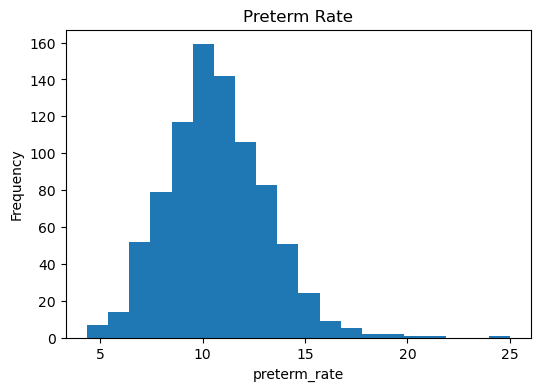

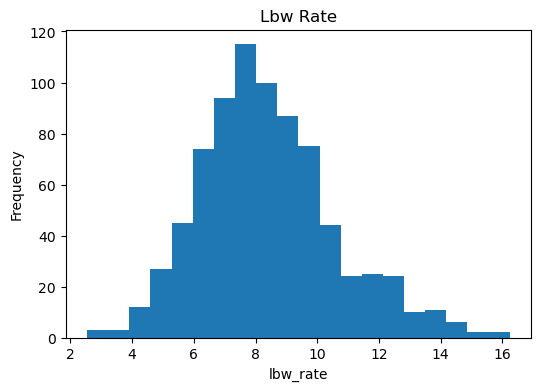

In [44]:
# Outcome distribution
import matplotlib.pyplot as plt
outcomes = [
    "preterm_rate",
    "lbw_rate"
]

for var in outcomes:

    plt.figure(figsize=(6,4))

    plt.hist(
        final_df[var].dropna(),
        bins=20
    )

    plt.title(var.replace("_"," ").title())
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

The histograms show the distribution of continuous variables included in the analysis. Several variables exhibit moderate skewness, which is common in county-level public health data. Overall, the distributions provide useful insight into the variability of maternal health indicators across Missouri counties.

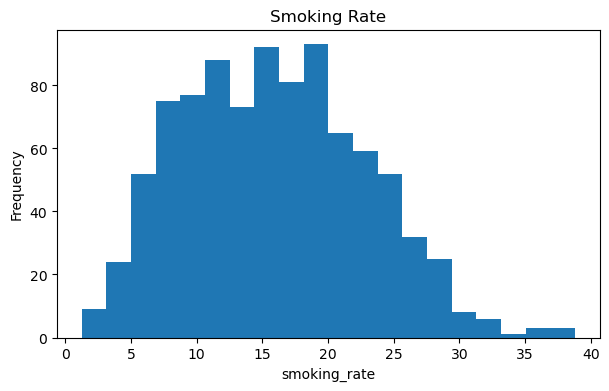

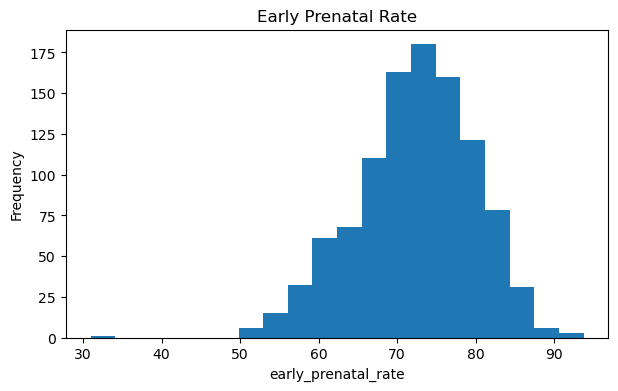

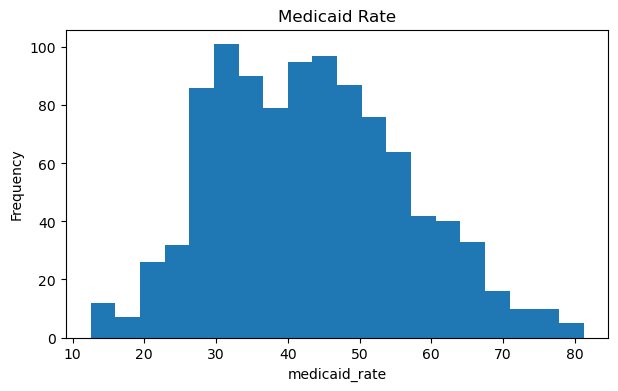

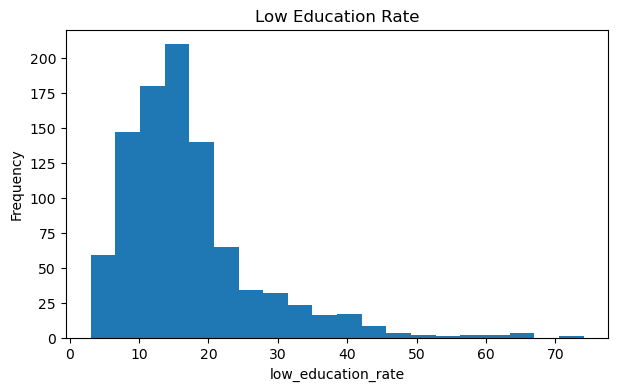

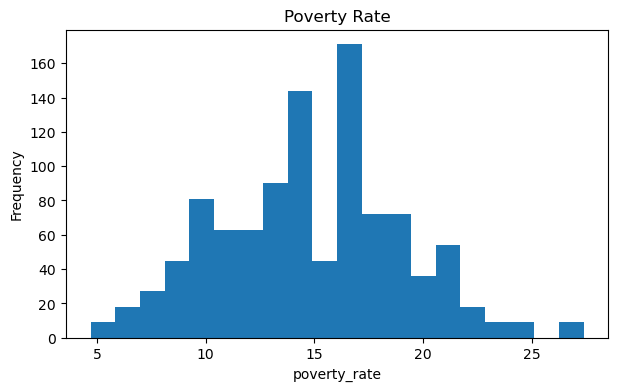

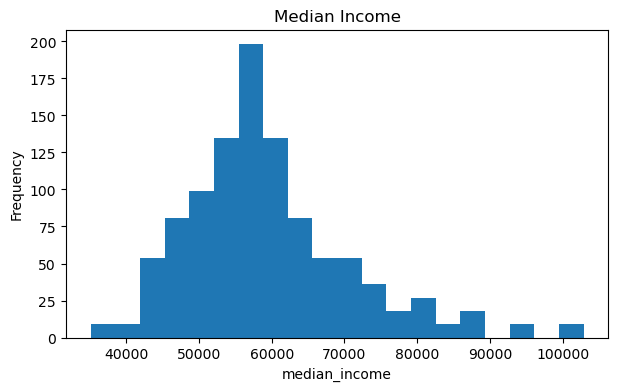

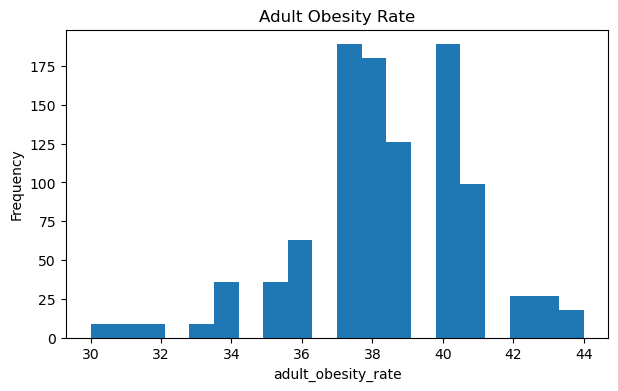

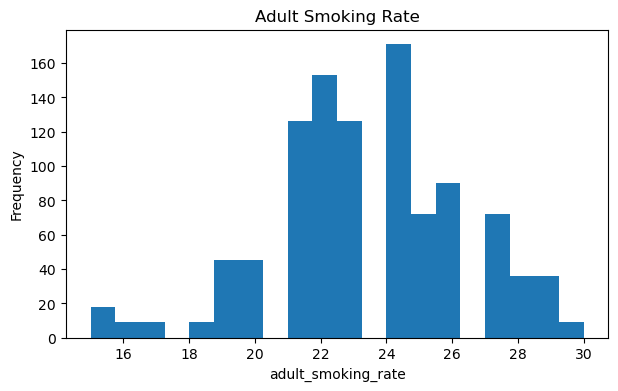

In [45]:
# Predictor distributor
predictors = [

    "smoking_rate",

    "early_prenatal_rate",

    "medicaid_rate",

    "low_education_rate",

    "poverty_rate",

    "median_income",

    "adult_obesity_rate",

    "adult_smoking_rate"

]

for var in predictors:

    plt.figure(figsize=(7,4))

    plt.hist(
        final_df[var].dropna(),
        bins=20
    )

    plt.title(var.replace("_"," ").title())

    plt.xlabel(var)

    plt.ylabel("Frequency")

    plt.show()

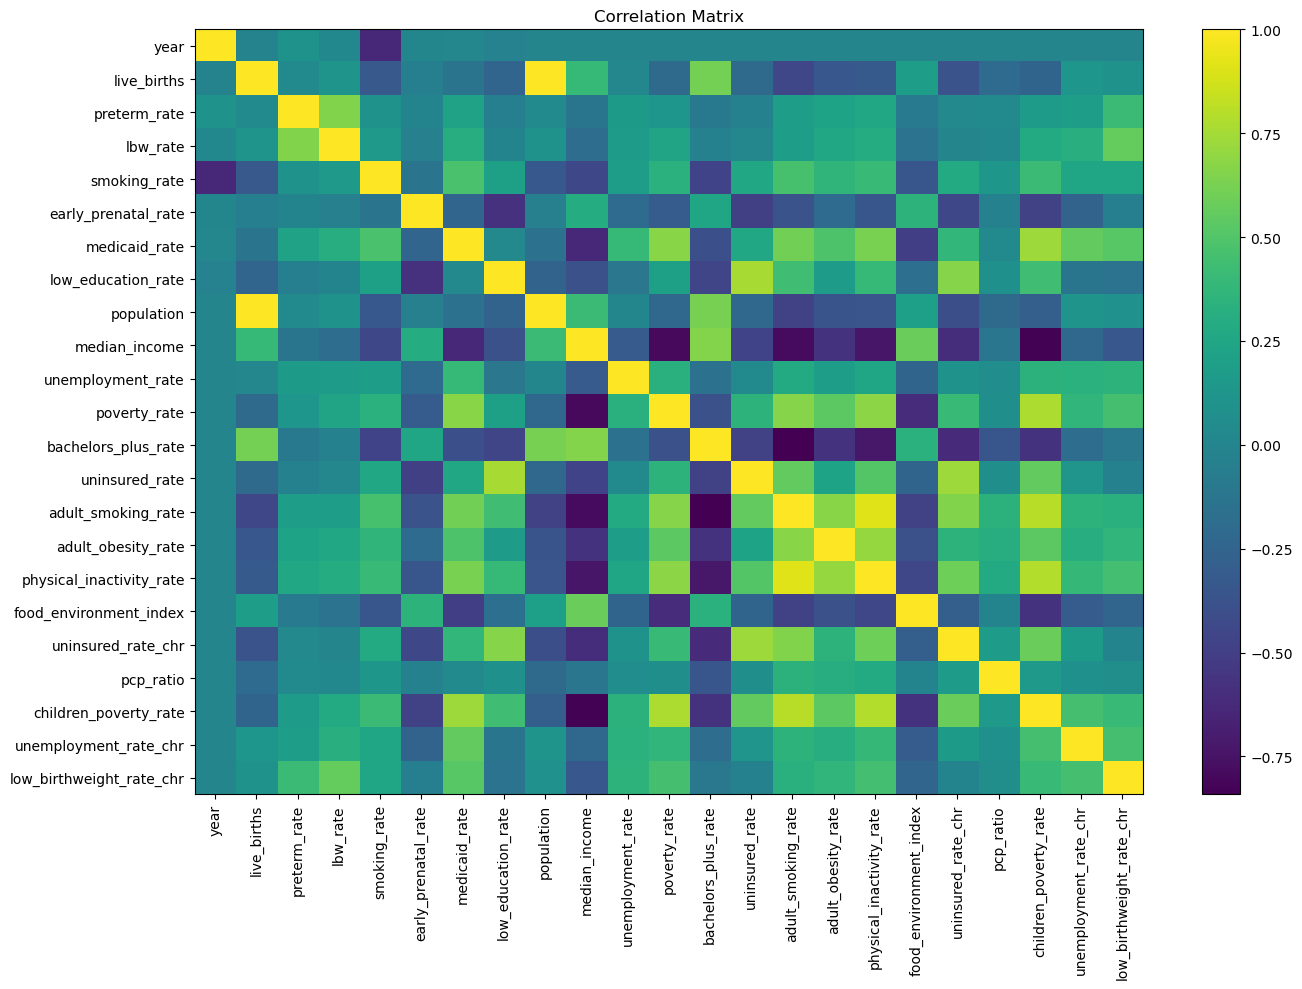

In [46]:
# Correlation Heatmap

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [47]:
# Correlation with preterm rate 

corr_preterm = (
    numeric_df.corr()["preterm_rate"]
    .sort_values(ascending=False)
)

display(
    corr_preterm.to_frame(
        "Correlation with Preterm Rate"
    )
)

,Correlation with Preterm Rate
preterm_rate,1.000000
lbw_rate,0.651343
low_birthweight_rate_chr,0.413899
physical_inactivity_rate,0.259079
adult_obesity_rate,0.223979
medicaid_rate,0.222920
unemployment_rate_chr,0.194278
adult_smoking_rate,0.183321
children_poverty_rate,0.176916
unemployment_rate,0.164426


In [48]:
# Correlation with LBW rate

corr_lbw = (
    numeric_df.corr()["lbw_rate"]
    .sort_values(ascending=False)
)

display(
    corr_lbw.to_frame(
        "Correlation with LBW Rate"
    )
)

,Correlation with LBW Rate
lbw_rate,1.000000
preterm_rate,0.651343
low_birthweight_rate_chr,0.565523
unemployment_rate_chr,0.313579
medicaid_rate,0.305496
physical_inactivity_rate,0.295685
children_poverty_rate,0.280997
adult_obesity_rate,0.255008
poverty_rate,0.233585
adult_smoking_rate,0.188054


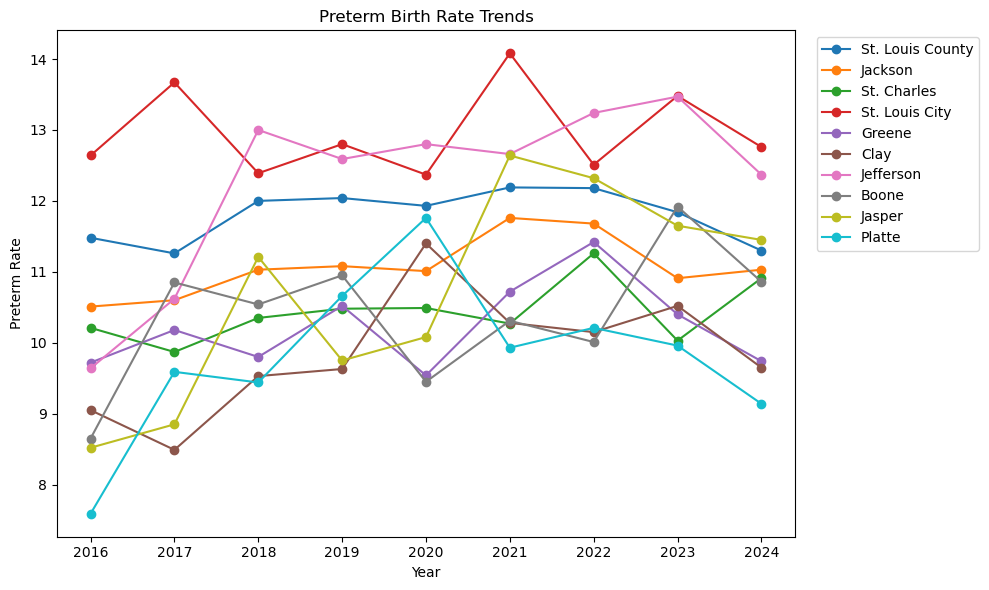

In [49]:
# County trends
top_counties = (
    final_df.groupby("county")["live_births"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(10,6))

for county in top_counties:

    subset = final_df[
        final_df["county"]==county
    ]

    plt.plot(
        subset["year"],
        subset["preterm_rate"],
        marker="o",
        label=county
    )

plt.legend(
    bbox_to_anchor=(1.02,1)
)

plt.title("Preterm Birth Rate Trends")

plt.xlabel("Year")

plt.ylabel("Preterm Rate")

plt.tight_layout()

plt.show()

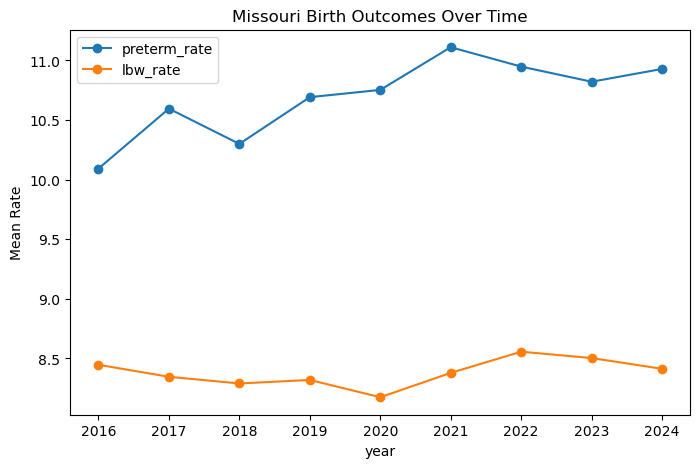

In [50]:
# Missouri time trend

trend = (
    final_df
    .groupby("year")[
        [
            "preterm_rate",
            "lbw_rate"
        ]
    ]
    .mean()
)

trend.plot(
    figsize=(8,5),
    marker="o"
)

plt.ylabel("Mean Rate")

plt.title("Missouri Birth Outcomes Over Time")

plt.show()

In [51]:
import geopandas as gpd

print(gpd.__version__)

1.1.4


## Geographic Distribution of Preterm Birth Risk

County-level choropleth maps were created to visualize spatial variation in birth outcomes across Missouri counties. Mapping helps identify geographic clusters of elevated risk that may warrant additional public health attention.

In [52]:
# Load county shapefile

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

SHAPE_PATH = Path(
    r"C:\Users\yemel\Downloads\Capstone dataset\Missouri County Boundaries"
)

us_counties = gpd.read_file(
    SHAPE_PATH / "cb_2014_us_county_20m.shp"
)

print("US counties shape:", us_counties.shape)
display(us_counties.head())

C:\Users\yemel\anaconda3\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


US counties shape: (3220, 10)


,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,16,017,00395158,0500000US16017,16017,Bonner,06,4492522387,478947473,"POLYGON Z ((-117.04121 48.04556 0, -117.04111 ..."
1,18,087,00450368,0500000US18087,18087,LaGrange,06,983230790,18324388,"POLYGON Z ((-85.65975 41.75924 0, -85.29218 41..."
2,41,027,01155131,0500000US41027,41027,Hood River,06,1351717731,29106847,"POLYGON Z ((-121.92396 45.65428 0, -121.90086 ..."
3,48,273,01383922,0500000US48273,48273,Kleberg,06,2282585635,541039916,"POLYGON Z ((-98.05946 27.63586 0, -97.94215 27..."
4,47,085,01639757,0500000US47085,47085,Humphreys,06,1374665964,67186875,"POLYGON Z ((-88.02239 35.96582 0, -87.91904 36..."


In [53]:
# Keeping MO counties only

missouri_map = us_counties[
    us_counties["STATEFP"] == "29"
].copy()

print("Missouri counties:", len(missouri_map))
display(missouri_map[["NAME", "GEOID"]].head())

Missouri counties: 115


,NAME,GEOID
20,Taney,29213
35,Adair,29001
41,Ripley,29181
76,Miller,29131
112,Callaway,29027


In [54]:
# Creating unique county names to ease merging 
missouri_map["county"] = missouri_map["NAME"].astype(str).str.strip()

# Distinguish St. Louis County from St. Louis independent city
missouri_map.loc[
    (missouri_map["NAME"] == "St. Louis") &
    (missouri_map["LSAD"].astype(str) == "06"),
    "county"
] = "St. Louis County"

missouri_map.loc[
    (missouri_map["NAME"] == "St. Louis") &
    (missouri_map["LSAD"].astype(str) == "25"),
    "county"
] = "St. Louis City"

print("Map rows:", len(missouri_map))
print("Unique county names:", missouri_map["county"].nunique())
print("Duplicate county names:", missouri_map["county"].duplicated().sum())

Map rows: 115
Unique county names: 115
Duplicate county names: 0


In [55]:
# create county-level averages, 2016-2024
county_summary = (
    final_df
    .groupby("county", as_index=False)
    .agg(
        average_preterm_rate=("preterm_rate", "mean"),
        average_lbw_rate=("lbw_rate", "mean"),
        average_smoking_rate=("smoking_rate", "mean"),
        average_medicaid_rate=("medicaid_rate", "mean")
    )
)

display(county_summary.head())

,county,average_preterm_rate,average_lbw_rate,average_smoking_rate,average_medicaid_rate
0,Adair,10.574444,8.464444,13.134444,37.674444
1,Andrew,8.941111,6.847778,11.822222,28.708889
2,Atchison,NaN,NaN,NaN,NaN
3,Audrain,11.251111,9.651111,18.512222,42.093333
4,Barry,10.785556,8.197778,15.377778,53.298889


In [56]:
# Merge Map with county outcome
map_df = missouri_map.merge(
    county_summary,
    on="county",
    how="left",
    validate="one_to_one"
)

print("Map rows:", len(map_df))
print(
    "Missing average preterm rates:",
    map_df["average_preterm_rate"].isna().sum()
)

Map rows: 115
Missing average preterm rates: 20


In [57]:
# Identify counties with missing map values
missing_map_counties = map_df.loc[
    map_df["average_preterm_rate"].isna(),
    ["county"]
].sort_values("county")

display(missing_map_counties)

print(
    "Number of counties with missing average preterm rate:",
    len(missing_map_counties)
)

,county
66,Atchison
37,Carroll
73,Carter
45,Chariton
12,Daviess
101,DeKalb
30,Gentry
20,Harrison
91,Holt
8,Knox


Number of counties with missing average preterm rate: 20


In [58]:
# Checking whether counties match btn map and dat

map_counties = set(missouri_map["county"])
summary_counties = set(county_summary["county"])

print("Counties in map but not in county summary:")
print(sorted(map_counties - summary_counties))

print("\nCounties in county summary but not in map:")
print(sorted(summary_counties - map_counties))

Counties in map but not in county summary:
[]

Counties in county summary but not in map:
[]


In [59]:
# Count available preterm years per county 

preterm_coverage = (
    final_df.groupby("county")["preterm_rate"]
    .agg(
        available_years="count",
        missing_years=lambda x: x.isna().sum()
    )
    .reset_index()
)

display(
    preterm_coverage[
        preterm_coverage["available_years"] == 0
    ].sort_values("county")
)

,county,available_years,missing_years
2,Atchison,0,9
16,Carroll,0,9
17,Carter,0,9
20,Chariton,0,9
30,Daviess,0,9
31,DeKalb,0,9
37,Gentry,0,9
40,Harrison,0,9
43,Holt,0,9
51,Knox,0,9


In [60]:
# Standardise shapefile county names

missouri_map["county"] = missouri_map["NAME"].astype(str).str.strip()

missouri_map["county"] = missouri_map["county"].replace({
    "St. Louis": "St. Louis County",
    "St. Louis city": "St. Louis City"
})

print(sorted(missouri_map["county"].unique())[-10:])

['Sullivan', 'Taney', 'Texas', 'Vernon', 'Warren', 'Washington', 'Wayne', 'Webster', 'Worth', 'Wright']


In [61]:
# Checking duplicate county names in map 
duplicates = missouri_map[
    missouri_map["county"].duplicated(keep=False)
][["NAME", "LSAD", "GEOID", "county"]]

display(duplicates)

,NAME,LSAD,GEOID,county
119,St. Louis,25,29510,St. Louis County
3103,St. Louis,06,29189,St. Louis County


In [62]:
# Creating unique MO county names 

missouri_map["county"] = missouri_map["NAME"].astype(str).str.strip()

# LSAD 25 represents an independent city
missouri_map.loc[
    (missouri_map["NAME"] == "St. Louis") &
    (missouri_map["LSAD"].astype(str) == "25"),
    "county"
] = "St. Louis City"

# LSAD 06 represents a county
missouri_map.loc[
    (missouri_map["NAME"] == "St. Louis") &
    (missouri_map["LSAD"].astype(str) == "06"),
    "county"
] = "St. Louis County"

print("Map rows:", len(missouri_map))
print("Unique county names:", missouri_map["county"].nunique())
print(
    "Duplicate county names:",
    missouri_map["county"].duplicated().sum()
)

display(
    missouri_map[
        missouri_map["county"].str.contains(
            "St. Louis",
            case=False,
            na=False
        )
    ][["NAME", "LSAD", "GEOID", "county"]]
)

Map rows: 115
Unique county names: 115
Duplicate county names: 0


,NAME,LSAD,GEOID,county
119,St. Louis,25,29510,St. Louis City
3103,St. Louis,06,29189,St. Louis County


In [63]:
print(
    "County summary rows:",
    len(county_summary)
)

print(
    "Unique counties:",
    county_summary["county"].nunique()
)

print(
    "Duplicate counties:",
    county_summary["county"].duplicated().sum()
)

County summary rows: 115
Unique counties: 115
Duplicate counties: 0


In [64]:
map_counties = set(missouri_map["county"])
data_counties = set(county_summary["county"])

print("Only in map:")
print(sorted(map_counties - data_counties))

print("\nOnly in outcome data:")
print(sorted(data_counties - map_counties))

Only in map:
[]

Only in outcome data:
[]


In [65]:
# Merge map with county outcomes

map_df = missouri_map.merge(
    county_summary,
    on="county",
    how="left",
    validate="one_to_one"
)

print("Map rows:", len(map_df))
print(
    "Missing preterm values:",
    map_df["average_preterm_rate"].isna().sum()
)

Map rows: 115
Missing preterm values: 20


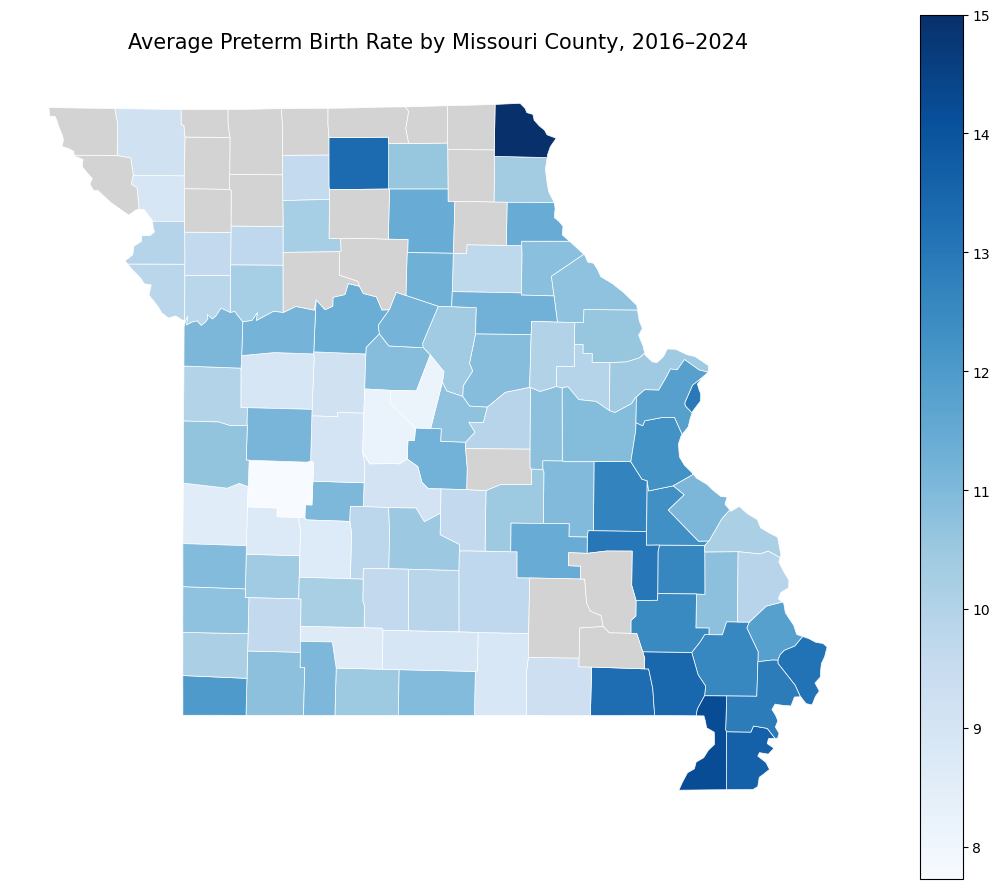

In [75]:
# Save preterm birth map

fig, ax = plt.subplots(figsize=(11, 9))

map_df.plot(
    column="average_preterm_rate",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "white",
        "label": "Suppressed or unavailable"
    }
)

ax.set_title(
    "Average Preterm Birth Rate by Missouri County, 2016–2024",
    fontsize=15,
    pad=15
)

ax.axis("off")
plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "average_preterm_rate_missouri_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
# TOP 10 COUNTIES BY AVERAGE PRETERM BIRTH RATE
top_preterm_counties = (
    county_summary[
        ["county", "average_preterm_rate"]
    ]
    .dropna()
    .sort_values(
        "average_preterm_rate",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_preterm_counties.index = (
    top_preterm_counties.index + 1
)

display(top_preterm_counties)

,county,average_preterm_rate
1,Clark,15.000000
2,Dunklin,14.214444
3,Pemiscot,13.632222
4,Butler,13.453333
5,Sullivan,13.342222
6,Ripley,13.294444
7,Mississippi,13.142222
8,Iron,13.010000
9,St. Louis City,12.966667
10,New Madrid,12.892222


In [77]:
top_preterm_counties.to_csv(
    OUTPUT_PATH / "top_10_preterm_counties.csv",
    index=False
)

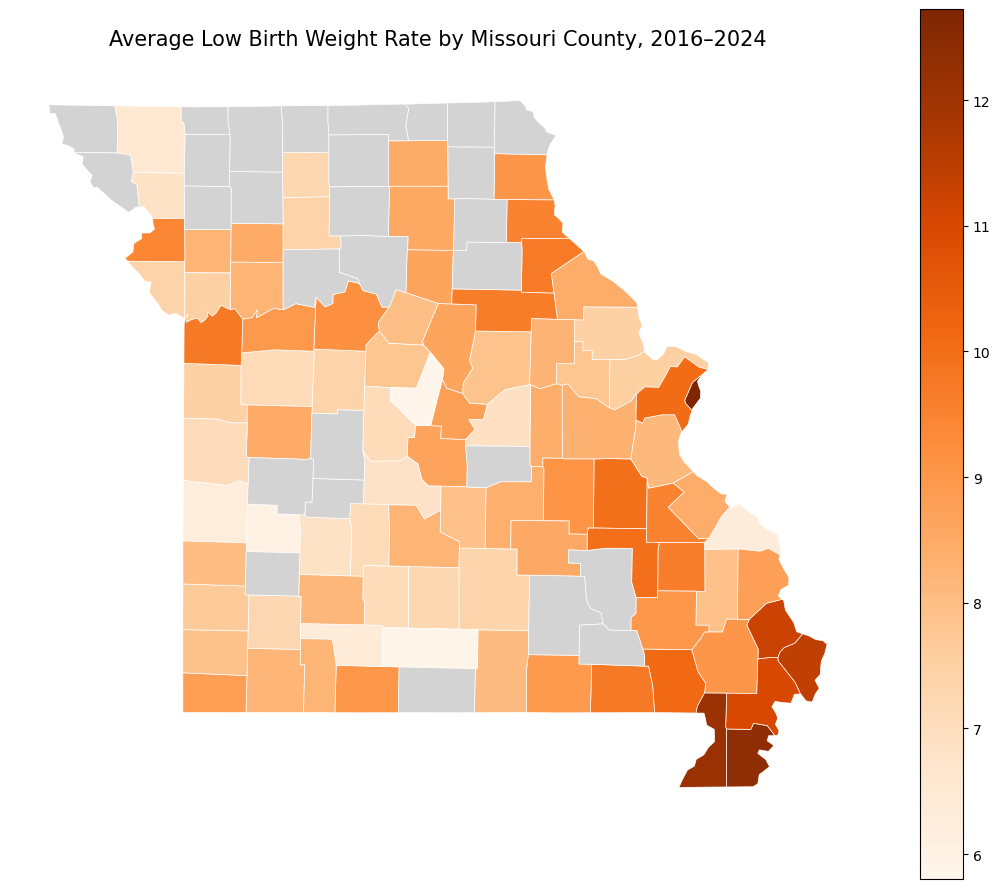

In [78]:
# MAP: AVERAGE LOW BIRTH WEIGHT RATE

fig, ax = plt.subplots(figsize=(11, 9))

map_df.plot(
    column="average_lbw_rate",
    cmap="Oranges",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "white",
        "label": "Suppressed or unavailable"
    }
)

ax.set_title(
    "Average Low Birth Weight Rate by Missouri County, 2016–2024",
    fontsize=15,
    pad=15
)

ax.axis("off")
plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "average_lbw_rate_missouri_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


The geographic visualizations reveal noticeable differences in maternal health indicators across Missouri counties. Some regions consistently exhibit higher rates of adverse maternal outcomes, highlighting potential geographic disparities that may warrant targeted public health interventions.

In [79]:
# STATEWIDE WEIGHTED OUTCOME TRENDS


def weighted_average(group, value_col, weight_col="live_births"):
    valid = group[[value_col, weight_col]].dropna()

    if valid.empty or valid[weight_col].sum() == 0:
        return np.nan

    return np.average(
        valid[value_col],
        weights=valid[weight_col]
    )


statewide_trends = (
    final_df.groupby("year")
    .apply(
        lambda group: pd.Series({
            "preterm_rate": weighted_average(
                group,
                "preterm_rate"
            ),
            "lbw_rate": weighted_average(
                group,
                "lbw_rate"
            )
        }),
        include_groups=False
    )
    .reset_index()
)

display(statewide_trends)

,year,preterm_rate,lbw_rate
0,2016,10.205469,8.756534
1,2017,10.593480,8.744520
2,2018,10.756920,8.780772
3,2019,10.924231,8.920328
4,2020,10.995228,8.778338
5,2021,11.325076,8.965932
6,2022,11.356790,9.195669
7,2023,11.085555,9.002582
8,2024,10.959478,8.838113


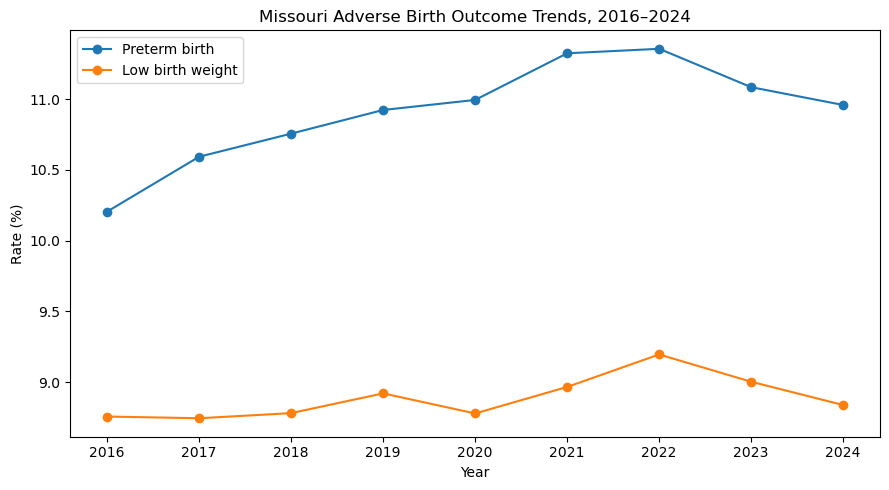

In [80]:
# Plot statewide outcome trend

plt.figure(figsize=(9, 5))

plt.plot(
    statewide_trends["year"],
    statewide_trends["preterm_rate"],
    marker="o",
    label="Preterm birth"
)

plt.plot(
    statewide_trends["year"],
    statewide_trends["lbw_rate"],
    marker="o",
    label="Low birth weight"
)

plt.xlabel("Year")
plt.ylabel("Rate (%)")
plt.title(
    "Missouri Adverse Birth Outcome Trends, 2016–2024"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "missouri_birth_outcome_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
# Correlations with PRETERM and LBW rates
numeric_df = final_df.select_dtypes(
    include=np.number
)

preterm_correlations = (
    numeric_df.corr()["preterm_rate"]
    .drop(
        labels=["preterm_rate"],
        errors="ignore"
    )
    .sort_values(ascending=False)
)

lbw_correlations = (
    numeric_df.corr()["lbw_rate"]
    .drop(
        labels=["lbw_rate"],
        errors="ignore"
    )
    .sort_values(ascending=False)
)

print("Correlations with preterm birth rate")
display(
    preterm_correlations.to_frame(
        "Correlation"
    )
)

print("Correlations with low birth weight rate")
display(
    lbw_correlations.to_frame(
        "Correlation"
    )
)

Correlations with preterm birth rate


,Correlation
lbw_rate,0.651343
low_birthweight_rate_chr,0.413899
physical_inactivity_rate,0.259079
adult_obesity_rate,0.223979
medicaid_rate,0.222920
unemployment_rate_chr,0.194278
adult_smoking_rate,0.183321
children_poverty_rate,0.176916
unemployment_rate,0.164426
poverty_rate,0.126035


Correlations with low birth weight rate


,Correlation
preterm_rate,0.651343
low_birthweight_rate_chr,0.565523
unemployment_rate_chr,0.313579
medicaid_rate,0.305496
physical_inactivity_rate,0.295685
children_poverty_rate,0.280997
adult_obesity_rate,0.255008
poverty_rate,0.233585
adult_smoking_rate,0.188054
unemployment_rate,0.167904


In [82]:
# Outcome missingness by birth volume
final_df["preterm_missing"] = (
    final_df["preterm_rate"].isna().astype(int)
)

final_df["lbw_missing"] = (
    final_df["lbw_rate"].isna().astype(int)
)

missingness_comparison = (
    final_df.groupby("preterm_missing")[
        "live_births"
    ]
    .agg(["count", "mean", "median", "min", "max"])
)

display(missingness_comparison)

,count,mean,median,min,max
preterm_missing,,,,,
0,855,727.409357,263.0,56,11673
1,180,75.322222,76.0,16,163


In [83]:
# Analysis checkpoint
print("Final dataset:", final_df.shape)
print("Counties:", final_df["county"].nunique())
print("Years:", sorted(final_df["year"].unique()))

print("\nDuplicate county-year rows:")
print(final_df.duplicated(["county", "year"]).sum())

required_columns = [
    "county",
    "year",
    "live_births",
    "preterm_rate",
    "lbw_rate",
    "smoking_rate",
    "early_prenatal_rate",
    "medicaid_rate",
    "low_education_rate",
    "median_income",
    "poverty_rate",
    "bachelors_plus_rate",
    "uninsured_rate",
    "adult_smoking_rate",
    "adult_obesity_rate",
    "physical_inactivity_rate",
    "food_environment_index",
    "children_poverty_rate",
    "unemployment_rate_chr",
    "pcp_ratio"
]

missing_columns = [
    col for col in required_columns
    if col not in final_df.columns
]

print("\nMissing required columns:")
print(missing_columns)

Final dataset: (1035, 26)
Counties: 115
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Duplicate county-year rows:
0

Missing required columns:
[]


In [84]:
# Removing temporary missingness columns
final_df = final_df.drop(
    columns=[
        "preterm_missing",
        "lbw_missing"
    ],
    errors="ignore"
)

print(final_df.shape)

(1035, 24)


In [85]:
# Save Analysis-ready checkpoint
analysis_file = (
    OUTPUT_PATH /
    "missouri_birth_outcomes_analysis_ready.csv"
)

final_df.to_csv(
    analysis_file,
    index=False
)

print("Saved:", analysis_file)

Saved: C:\Users\yemel\Downloads\Capstone dataset\Processed Data\missouri_birth_outcomes_analysis_ready.csv


In [86]:
# Creating preterm modeling dataset 


preterm_df = final_df.copy()

# Keep only observations with a measured preterm rate
preterm_df = preterm_df.dropna(subset=["preterm_rate"])

print("Observations:", len(preterm_df))
print("Counties:", preterm_df["county"].nunique())

Observations: 855
Counties: 95


In [87]:
# Candidate predictors

candidate_predictors = [

    "smoking_rate",

    "early_prenatal_rate",

    "medicaid_rate",

    "low_education_rate",

    "population",

    "median_income",

    "unemployment_rate",

    "poverty_rate",

    "bachelors_plus_rate",

    "uninsured_rate",

    "adult_smoking_rate",

    "adult_obesity_rate",

    "physical_inactivity_rate",

    "food_environment_index",

    "uninsured_rate_chr",

    "pcp_ratio",

    "children_poverty_rate",

    "unemployment_rate_chr",

    "low_birthweight_rate_chr"

]

print("Number of predictors:", len(candidate_predictors))

Number of predictors: 19


In [88]:
# missing values

missing = (
    preterm_df[candidate_predictors]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing)

low_education_rate          45
smoking_rate                36
pcp_ratio                   18
unemployment_rate_chr        9
low_birthweight_rate_chr     9
children_poverty_rate        9
adult_smoking_rate           9
physical_inactivity_rate     9
food_environment_index       9
adult_obesity_rate           9
uninsured_rate_chr           9
medicaid_rate                0
early_prenatal_rate          0
uninsured_rate               0
bachelors_plus_rate          0
population                   0
median_income                0
poverty_rate                 0
unemployment_rate            0
dtype: int64

In [89]:
# Complete cases

vif_df = preterm_df[
    candidate_predictors
].dropna()

print(vif_df.shape)

(765, 19)


## Multicollinearity Assessment

Variance Inflation Factors (VIF) were calculated to quantify multicollinearity among predictors. Variables exhibiting excessive multicollinearity were evaluated before model fitting to improve model stability and interpretability.

In [90]:
# VARIANCE INFLATION FACTOR (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = vif_df.columns

vif["VIF"] = [

    variance_inflation_factor(
        vif_df.values,
        i
    )

    for i in range(vif_df.shape[1])

]

vif = vif.sort_values(
    "VIF",
    ascending=False
)

display(vif)

,Variable,VIF
12,physical_inactivity_rate,722.682569
10,adult_smoking_rate,715.953701
11,adult_obesity_rate,401.235781
13,food_environment_index,181.163678
1,early_prenatal_rate,180.976580
5,median_income,162.293910
14,uninsured_rate_chr,141.027104
16,children_poverty_rate,93.595784
18,low_birthweight_rate_chr,82.386838
7,poverty_rate,71.488688


In [91]:
regression_predictors = [
    "smoking_rate",
    "early_prenatal_rate",
    "medicaid_rate",
    "median_income",
    "low_education_rate",
    "adult_obesity_rate",
    "pcp_ratio"
]

In [92]:
vif_df = preterm_df[
    regression_predictors
].dropna()

In [93]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame({
    "Variable": vif_df.columns,
    "VIF": [
        variance_inflation_factor(vif_df.values, i)
        for i in range(vif_df.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

,Variable,VIF
5,adult_obesity_rate,176.919864
1,early_prenatal_rate,124.111032
3,median_income,43.789847
2,medicaid_rate,28.106487
0,smoking_rate,8.743674
4,low_education_rate,7.663672
6,pcp_ratio,2.260294


## Feature Selection

Recursive Feature Elimination (RFE) was used to identify the most informative predictors for subsequent machine learning models while reducing redundant variables.

In [94]:
# FEATURE SELECTION (RFE)
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

In [95]:
# Predictors for RFE

rfe_predictors = [

    "smoking_rate",
    "early_prenatal_rate",
    "medicaid_rate",
    "low_education_rate",

    "median_income",
    "unemployment_rate",
    "poverty_rate",
    "bachelors_plus_rate",
    "uninsured_rate",

    "adult_smoking_rate",
    "adult_obesity_rate",
    "physical_inactivity_rate",
    "food_environment_index",

    "uninsured_rate_chr",
    "pcp_ratio",
    "children_poverty_rate",
    "unemployment_rate_chr"

]

target = "preterm_rate"

In [96]:
# Creating a modeling dataset

rfe_df = final_df[
    rfe_predictors + [target]
].copy()

rfe_df = rfe_df.dropna(subset=[target])

print(rfe_df.shape)

(855, 18)


In [97]:
# Impute prewdictors

X = rfe_df[rfe_predictors]

y = rfe_df[target]

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(

    imputer.fit_transform(X),

    columns=rfe_predictors

)

print(X.shape)

(855, 17)


In [98]:
# RFE

rf = RandomForestRegressor(

    n_estimators=500,

    random_state=42

)

rfe = RFE(

    estimator=rf,

    n_features_to_select=10

)

rfe.fit(X, y)

RFE(estimator=RandomForestRegressor(n_estimators=500, random_state=42),
    n_features_to_select=10)

In [99]:
# Selected features

selected_features = pd.DataFrame({

    "Variable": X.columns,

    "Selected": rfe.support_,

    "Ranking": rfe.ranking_

})

selected_features = selected_features.sort_values(

    "Ranking"

)

display(selected_features)

,Variable,Selected,Ranking
0,smoking_rate,True,1
1,early_prenatal_rate,True,1
2,medicaid_rate,True,1
3,low_education_rate,True,1
4,median_income,True,1
5,unemployment_rate,True,1
7,bachelors_plus_rate,True,1
8,uninsured_rate,True,1
14,pcp_ratio,True,1
11,physical_inactivity_rate,True,1


In [100]:
# Store RFE-selected features
selected_rfe_features = (
    selected_features.loc[
        selected_features["Selected"],
        "Variable"
    ]
    .tolist()
)

print("Selected features:", len(selected_rfe_features))
print(selected_rfe_features)

Selected features: 10
['smoking_rate', 'early_prenatal_rate', 'medicaid_rate', 'low_education_rate', 'median_income', 'unemployment_rate', 'bachelors_plus_rate', 'uninsured_rate', 'pcp_ratio', 'physical_inactivity_rate']


# Regression Modeling

The first modeling task treated preterm birth rate as a continuous outcome. Six regression models were evaluated using grouped cross-validation to compare predictive performance across Missouri counties.

In [101]:
# PRETERM REGRESSION MODELING SAMPLE
preterm_model_df = final_df.dropna(
    subset=["preterm_rate"]
).copy()

X_preterm = preterm_model_df[selected_rfe_features].copy()
y_preterm = preterm_model_df["preterm_rate"].copy()
groups_preterm = preterm_model_df["county"].copy()

print("Observations:", len(preterm_model_df))
print("Counties:", groups_preterm.nunique())
print("Predictors:", X_preterm.shape[1])

Observations: 855
Counties: 95
Predictors: 10


In [102]:
# GROUPED TRAIN-TEST SPLIT BY COUNTY
from sklearn.model_selection import GroupShuffleSplit

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(
        X_preterm,
        y_preterm,
        groups=groups_preterm
    )
)

X_train = X_preterm.iloc[train_idx].copy()
X_test = X_preterm.iloc[test_idx].copy()

y_train = y_preterm.iloc[train_idx].copy()
y_test = y_preterm.iloc[test_idx].copy()

train_counties = groups_preterm.iloc[train_idx]
test_counties = groups_preterm.iloc[test_idx]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Training counties:", train_counties.nunique())
print("Testing counties:", test_counties.nunique())

print(
    "County overlap:",
    len(set(train_counties) & set(test_counties))
)

Training observations: 684
Testing observations: 171
Training counties: 76
Testing counties: 19
County overlap: 0


In [103]:
# Modeling libraries

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

In [104]:
# LINEAR REGRESSION PIPELINE
linear_model = Pipeline([

    ("imputer",
     SimpleImputer(strategy="median")),

    ("model",
     LinearRegression())

])

linear_model.fit(

    X_train,

    y_train

)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model', LinearRegression())])

In [105]:
# Predictions

train_predictions = linear_model.predict(X_train)

test_predictions = linear_model.predict(X_test)

In [106]:
# Model performance

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_predictions
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

train_mae = mean_absolute_error(
    y_train,
    train_predictions
)

test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

train_r2 = r2_score(
    y_train,
    train_predictions
)

test_r2 = r2_score(
    y_test,
    test_predictions
)

results = pd.DataFrame({

    "Metric":[

        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE",
        "Train R²",
        "Test R²"

    ],

    "Value":[

        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_r2,
        test_r2

    ]

})

display(results)

,Metric,Value
0,Train RMSE,2.156807
1,Test RMSE,2.703985
2,Train MAE,1.659984
3,Test MAE,2.121451
4,Train R²,0.163856
5,Test R²,-0.012850


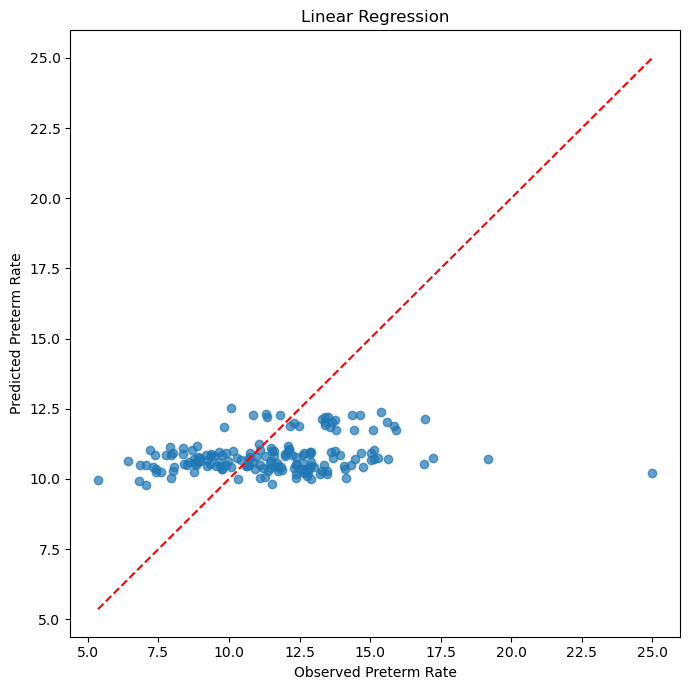

In [107]:
# OBSERVED VS PREDICTED


import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    test_predictions,

    alpha=0.7

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linestyle="--"

)

plt.xlabel("Observed Preterm Rate")

plt.ylabel("Predicted Preterm Rate")

plt.title("Linear Regression")

plt.tight_layout()

plt.show()

In [108]:
# REGRESSION COEFFICIENTS
coef = pd.DataFrame({

    "Variable":selected_rfe_features,

    "Coefficient":

    linear_model.named_steps[
        "model"
    ].coef_

})

coef = coef.sort_values(

    "Coefficient",

    key=np.abs,

    ascending=False

)

display(coef)

,Variable,Coefficient
9,physical_inactivity_rate,0.345489
5,unemployment_rate,0.160090
7,uninsured_rate,-0.141148
6,bachelors_plus_rate,0.024884
1,early_prenatal_rate,0.024349
2,medicaid_rate,0.019996
3,low_education_rate,-0.016775
0,smoking_rate,0.012141
4,median_income,0.000024
8,pcp_ratio,0.000002


In [109]:
# FIT RANDOM FOREST

rf_model = Pipeline([

    ("imputer", SimpleImputer(strategy="median")),

    ("model", RandomForestRegressor(

        n_estimators=500,

        random_state=42,

        max_depth=None,

        min_samples_leaf=2,

        n_jobs=-1

    ))

])

rf_model.fit(

    X_train,

    y_train

)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestRegressor(min_samples_leaf=2, n_estimators=500,
                                       n_jobs=-1, random_state=42))])

In [110]:
# Predictions

rf_train_pred = rf_model.predict(X_train)

rf_test_pred = rf_model.predict(X_test)

In [111]:
# RANDOM FOREST PERFORMANCE
rf_results = pd.DataFrame({

    "Metric":[

        "Train RMSE",

        "Test RMSE",

        "Train MAE",

        "Test MAE",

        "Train R²",

        "Test R²"

    ],

    "Value":[

        np.sqrt(mean_squared_error(y_train, rf_train_pred)),

        np.sqrt(mean_squared_error(y_test, rf_test_pred)),

        mean_absolute_error(y_train, rf_train_pred),

        mean_absolute_error(y_test, rf_test_pred),

        r2_score(y_train, rf_train_pred),

        r2_score(y_test, rf_test_pred)

    ]

})

display(rf_results)

,Metric,Value
0,Train RMSE,1.043707
1,Test RMSE,2.673719
2,Train MAE,0.767621
3,Test MAE,2.105625
4,Train R²,0.804199
5,Test R²,0.009697


In [125]:
# RANDOM FOREST FEATURE IMPORTANCE


importance = pd.DataFrame({

    "Variable": selected_rfe_features,

    "Importance":

    rf_model.named_steps["model"].feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

display(importance)

,Variable,Importance
2,medicaid_rate,0.168247
0,smoking_rate,0.157530
3,low_education_rate,0.152937
1,early_prenatal_rate,0.148809
9,physical_inactivity_rate,0.110497
6,bachelors_plus_rate,0.064391
7,uninsured_rate,0.061215
4,median_income,0.048063
5,unemployment_rate,0.045683
8,pcp_ratio,0.042628


In [126]:
# ============================================================
# GROUPED MODEL COMPARISON: IMPORTS
# ============================================================
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    GroupKFold,
    cross_validate
)
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [127]:
# Define preterm modeling data
ml_predictors = [
    "smoking_rate",
    "early_prenatal_rate",
    "medicaid_rate",
    "low_education_rate",
    "median_income",
    "unemployment_rate",
    "poverty_rate",
    "bachelors_plus_rate",
    "uninsured_rate",
    "adult_smoking_rate",
    "adult_obesity_rate",
    "physical_inactivity_rate",
    "food_environment_index",
    "uninsured_rate_chr",
    "pcp_ratio",
    "children_poverty_rate",
    "unemployment_rate_chr"
]

preterm_ml_df = (
    final_df
    .dropna(subset=["preterm_rate"])
    .copy()
)

X_ml = preterm_ml_df[ml_predictors].copy()
y_ml = preterm_ml_df["preterm_rate"].copy()
groups_ml = preterm_ml_df["county"].copy()

print("Observations:", len(preterm_ml_df))
print("Counties:", groups_ml.nunique())
print("Candidate predictors:", X_ml.shape[1])
print("Missing outcome values:", y_ml.isna().sum())

Observations: 855
Counties: 95
Candidate predictors: 17
Missing outcome values: 0


In [128]:
# COUNTY-GROUPED CROSS-VALIDATION


group_cv = GroupKFold(n_splits=5)

print("Number of grouped folds:", group_cv.get_n_splits())

Number of grouped folds: 5


In [129]:
# FEATURE SELECTOR USED INSIDE EACH TRAINING FOLD


fold_selector = RFE(
    estimator=RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    n_features_to_select=10,
    step=1
)

In [130]:
# IMPORT XGBOOST

from xgboost import XGBRegressor

XGBOOST_AVAILABLE = True

print("XGBoost is available.")

XGBoost is available.


In [131]:
# DEFINE REUSABLE MODEL PIPELINES


models = {
    "Linear Regression": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "selector",
            clone(fold_selector)
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LinearRegression()
        )
    ]),

    "Random Forest": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "selector",
            clone(fold_selector)
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=3,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "Gradient Boosting": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "selector",
            clone(fold_selector)
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.03,
                max_depth=2,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]),

    "SVR": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "selector",
            clone(fold_selector)
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            SVR(
                kernel="rbf",
                C=10,
                epsilon=0.2,
                gamma="scale"
            )
        )
    ]),

    "ANN": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "selector",
            clone(fold_selector)
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(32, 16),
                activation="relu",
                solver="adam",
                alpha=0.01,
                learning_rate_init=0.001,
                max_iter=3000,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=42
            )
        )
    ])
}
if XGBOOST_AVAILABLE:
    models["XGBoost"] = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "selector",
            clone(fold_selector)
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=3,
                min_child_weight=5,
                subsample=0.80,
                colsample_bytree=0.80,
                reg_alpha=0.10,
                reg_lambda=1.0,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ])


print("Models to evaluate:")
print(list(models.keys()))

Models to evaluate:
['Linear Regression', 'Random Forest', 'Gradient Boosting', 'SVR', 'ANN', 'XGBoost']


### Model Performance Comparison

Regression models were compared using RMSE, MAE, and R². Lower RMSE and MAE indicate improved prediction accuracy, whereas higher R² indicates greater explained variance.

In [132]:
# EVALUATE ALL MODELS USING COUNTY-GROUPED CV


scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

comparison_records = []
fold_records = []

for model_name, model in models.items():

    print(f"Evaluating: {model_name}")

    cv_output = cross_validate(
        estimator=model,
        X=X_ml,
        y=y_ml,
        groups=groups_ml,
        cv=group_cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=1,
        error_score="raise"
    )

    fold_rmse = -cv_output["test_RMSE"]
    fold_mae = -cv_output["test_MAE"]
    fold_r2 = cv_output["test_R2"]

    comparison_records.append({
        "Model": model_name,
        "Mean_RMSE": fold_rmse.mean(),
        "SD_RMSE": fold_rmse.std(ddof=1),
        "Mean_MAE": fold_mae.mean(),
        "SD_MAE": fold_mae.std(ddof=1),
        "Mean_R2": fold_r2.mean(),
        "SD_R2": fold_r2.std(ddof=1)
    })

    for fold_number in range(len(fold_rmse)):
        fold_records.append({
            "Model": model_name,
            "Fold": fold_number + 1,
            "RMSE": fold_rmse[fold_number],
            "MAE": fold_mae[fold_number],
            "R2": fold_r2[fold_number]
        })

model_comparison = (
    pd.DataFrame(comparison_records)
    .sort_values(
        ["Mean_RMSE", "Mean_MAE"],
        ascending=True
    )
    .reset_index(drop=True)
)

fold_results = pd.DataFrame(fold_records)

display(model_comparison.round(4))

Evaluating: Linear Regression
Evaluating: Random Forest
Evaluating: Gradient Boosting
Evaluating: SVR
Evaluating: ANN
Evaluating: XGBoost


,Model,Mean_RMSE,SD_RMSE,Mean_MAE,SD_MAE,Mean_R2,SD_R2
0,Linear Regression,2.3350,0.1482,1.7847,0.1394,0.0845,0.0492
1,Random Forest,2.3905,0.1461,1.8484,0.1542,0.0400,0.0562
2,Gradient Boosting,2.4462,0.1082,1.8902,0.1288,-0.0058,0.0363
3,XGBoost,2.4743,0.1258,1.9128,0.1406,-0.0295,0.0626
4,SVR,2.5575,0.2040,2.0354,0.2080,-0.1009,0.1292
5,ANN,2.6349,0.1524,2.0571,0.0839,-0.1690,0.1095


In [133]:
# FOLD-LEVEL MODEL PERFORMANCE


display(
    fold_results
    .sort_values(["Model", "Fold"])
    .round(4)
)

,Model,Fold,RMSE,MAE,R2
20,ANN,1,2.4999,1.9809,-0.1100
21,ANN,2,2.8712,2.1976,-0.3509
22,ANN,3,2.5754,2.0069,-0.1779
23,ANN,4,2.6988,2.0476,-0.0668
24,ANN,5,2.5292,2.0524,-0.1393
10,Gradient Boosting,1,2.3216,1.7451,0.0426
11,Gradient Boosting,2,2.4771,1.7853,-0.0055
12,Gradient Boosting,3,2.3849,1.8790,-0.0101
13,Gradient Boosting,4,2.6090,2.0246,0.0030
14,Gradient Boosting,5,2.4386,2.0171,-0.0590


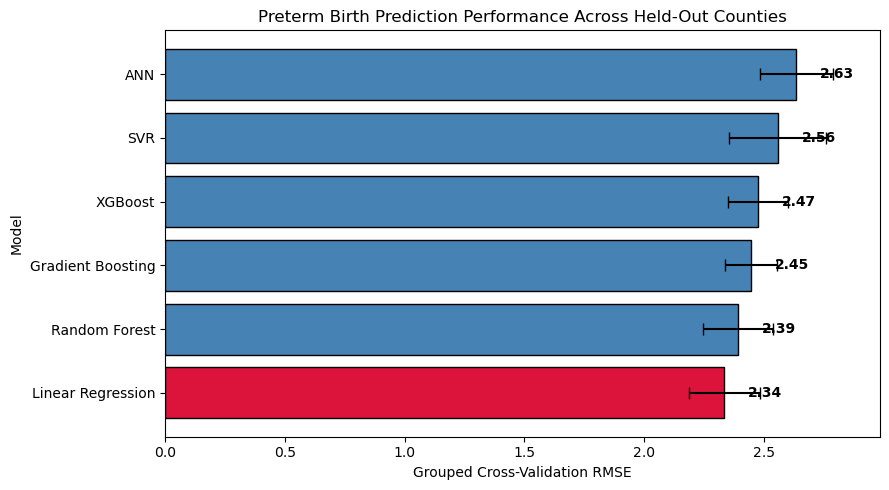

In [134]:
# Model comparison figure
import matplotlib.pyplot as plt

plot_df = model_comparison.sort_values(
    "Mean_RMSE",
    ascending=True
)

plt.figure(figsize=(9, 5))
# Color the best model differently
colors = ["crimson"] + ["steelblue"] * (len(plot_df) - 1)
plt.barh(
    plot_df["Model"],
    plot_df["Mean_RMSE"],
    xerr=plot_df["SD_RMSE"],
    capsize=4,
    color=colors,
    edgecolor="black"
)
# Add exact RMSE values
for i, value in enumerate(plot_df["Mean_RMSE"]):
    plt.text(
        value + 0.10,          # was 0.03
        i,
        f"{value:.2f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

plt.xlabel("Grouped Cross-Validation RMSE")
plt.ylabel("Model")
plt.title(
    "Preterm Birth Prediction Performance Across Held-Out Counties"
)
plt.xlim(0, max(plot_df["Mean_RMSE"]) + 0.35)
plt.tight_layout()
plt.show()

In [136]:
selected_features.to_csv(
    OUTPUT_PATH / "RFE_Selected_Features.csv",
    index=False
)

coef.to_csv(
    OUTPUT_PATH / "Linear_Regression_Coefficients.csv",
    index=False
)

importance.to_csv(
    OUTPUT_PATH / "Random_Forest_Feature_Importance.csv",
    index=False
)

In [137]:
model_comparison.to_csv(
    OUTPUT_PATH / "Model_Comparison_Regression.csv",
    index=False
)

fold_results.to_csv(
    OUTPUT_PATH / "Model_Fold_Results.csv",
    index=False
)

In [138]:
# Creating HIGH-RISK PRETERM OUTCOME


classification_df = final_df.copy()

# 75th percentile threshold
threshold = classification_df["preterm_rate"].quantile(0.75)

classification_df["high_risk_preterm"] = (
    classification_df["preterm_rate"] >= threshold
).astype(int)

print(f"75th percentile threshold: {threshold:.2f}%")

display(
    classification_df[
        ["preterm_rate", "high_risk_preterm"]
    ].head()
)

75th percentile threshold: 12.24%


,preterm_rate,high_risk_preterm
0,12.87,1
1,9.77,0
2,8.36,0
3,13.62,1
4,11.27,0


In [139]:
# Class distribution

class_summary = (
    classification_df["high_risk_preterm"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_summary["Percent"] = (
    class_summary["Count"] /
    class_summary["Count"].sum()
    * 100
)

display(class_summary)

print()

print(classification_df["high_risk_preterm"].value_counts(normalize=True))

,Class,Count,Percent
0,0,819,79.130435
1,1,216,20.869565



high_risk_preterm
0    0.791304
1    0.208696
Name: proportion, dtype: float64


In [140]:
# Look for predictor-related variables

[var for var in globals() if "predict" in var.lower()]

['predictors',
 'candidate_predictors',
 'regression_predictors',
 'rfe_predictors',
 'train_predictions',
 'test_predictions',
 'ml_predictors']

In [141]:
final_df.columns.tolist()

['county',
 'year',
 'live_births',
 'preterm_rate',
 'lbw_rate',
 'smoking_rate',
 'early_prenatal_rate',
 'medicaid_rate',
 'low_education_rate',
 'population',
 'median_income',
 'unemployment_rate',
 'poverty_rate',
 'bachelors_plus_rate',
 'uninsured_rate',
 'adult_smoking_rate',
 'adult_obesity_rate',
 'physical_inactivity_rate',
 'food_environment_index',
 'uninsured_rate_chr',
 'pcp_ratio',
 'children_poverty_rate',
 'unemployment_rate_chr',
 'low_birthweight_rate_chr']

# Classification Modeling

A binary outcome representing high-risk county-year observations was created using the upper quartile of the preterm birth rate distribution. Classification models were evaluated using grouped cross-validation to identify counties at elevated risk.

In [142]:
# Preparing data for classification

classification_predictors = X_ml.columns.tolist()

# This is important as it removes rows where preterm_rate is missing
classification_complete = classification_df.dropna(
    subset=["preterm_rate"]
).copy()

X_class = classification_complete[
    classification_predictors
].copy()

y_class = classification_complete[
    "high_risk_preterm"
].copy()

groups_class = classification_complete[
    "county"
].copy()

print("Observations:", len(classification_complete))
print("Counties:", groups_class.nunique())
print("Predictors:", len(classification_predictors))
print("\nClass distribution:")
print(y_class.value_counts())
print("\nClass percentages:")
print((y_class.value_counts(normalize=True) * 100).round(2))

Observations: 855
Counties: 95
Predictors: 17

Class distribution:
high_risk_preterm
0    639
1    216
Name: count, dtype: int64

Class percentages:
high_risk_preterm
0    74.74
1    25.26
Name: proportion, dtype: float64


In [143]:
# GROUPED CROSS-VALIDATION FOR CLASSIFICATION

from sklearn.model_selection import GroupKFold

group_cv_class = GroupKFold(n_splits=5)

print(
    "Number of grouped folds:",
    group_cv_class.get_n_splits()
)

Number of grouped folds: 5


In [144]:
# CLASSIFICATION FEATURE SELECTOR

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

fold_selector_class = RFE(
    estimator=RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    n_features_to_select=10,
    step=1
)

print("Classification selector created.")

Classification selector created.


In [145]:
# Define classification models
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

classification_models = {

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", clone(fold_selector_class)),
        ("scaler", StandardScaler()),
        ("model",
         LogisticRegression(
             class_weight="balanced",
             random_state=42,
             max_iter=5000
         ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", clone(fold_selector_class)),
        ("model",
         RandomForestClassifier(
             n_estimators=500,
             min_samples_leaf=3,
             max_features="sqrt",
             class_weight="balanced",
             random_state=42,
             n_jobs=-1
         ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", clone(fold_selector_class)),
        ("model",
         GradientBoostingClassifier(
             n_estimators=200,
             learning_rate=0.03,
             max_depth=2,
             random_state=42
         ))
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", clone(fold_selector_class)),
        ("scaler", StandardScaler()),
        ("model",
         SVC(
             probability=True,
             kernel="rbf",
             C=10,
             gamma="scale",
             class_weight="balanced",
             random_state=42
         ))
    ]),

    "ANN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", clone(fold_selector_class)),
        ("scaler", StandardScaler()),
        ("model",
         MLPClassifier(
             hidden_layer_sizes=(32,16),
             activation="relu",
             solver="adam",
             alpha=0.01,
             learning_rate_init=0.001,
             max_iter=3000,
             early_stopping=True,
             validation_fraction=0.15,
             random_state=42
         ))
    ]),

    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", clone(fold_selector_class)),
        ("model",
         XGBClassifier(
             n_estimators=300,
             learning_rate=0.03,
             max_depth=3,
             min_child_weight=5,
             subsample=0.80,
             colsample_bytree=0.80,
             objective="binary:logistic",
             eval_metric="logloss",
             random_state=42
         ))
    ])
}

print("Classification models:")
print(list(classification_models.keys()))

Classification models:
['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM', 'ANN', 'XGBoost']


In [146]:
# GROUPED CROSS-VALIDATION: CLASSIFICATION MODELS


from sklearn.model_selection import cross_validate

classification_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

classification_results = []
classification_fold_results = []
classification_failed = []

for model_name, model in classification_models.items():

    print(f"Evaluating: {model_name}")

    try:

        scores = cross_validate(
            estimator=model,
            X=X_class,
            y=y_class,
            groups=groups_class,
            cv=group_cv_class,
            scoring=classification_scoring,
            return_train_score=False,
            n_jobs=1,
            error_score="raise"
        )

        classification_results.append({

            "Model": model_name,

            "Accuracy": scores["test_accuracy"].mean(),
            "Precision": scores["test_precision"].mean(),
            "Recall": scores["test_recall"].mean(),
            "F1": scores["test_f1"].mean(),
            "ROC_AUC": scores["test_roc_auc"].mean(),
            "PR_AUC": scores["test_average_precision"].mean()

        })

        for fold in range(len(scores["test_accuracy"])):

            classification_fold_results.append({

                "Model": model_name,
                "Fold": fold + 1,

                "Accuracy": scores["test_accuracy"][fold],
                "Precision": scores["test_precision"][fold],
                "Recall": scores["test_recall"][fold],
                "F1": scores["test_f1"][fold],
                "ROC_AUC": scores["test_roc_auc"][fold],
                "PR_AUC": scores["test_average_precision"][fold]

            })

    except Exception as e:

        print(f"{model_name} failed")
        print(e)

        classification_failed.append({
            "Model": model_name,
            "Error": str(e)
        })

Evaluating: Logistic Regression
Evaluating: Random Forest
Evaluating: Gradient Boosting
Evaluating: SVM
Evaluating: ANN


C:\Users\yemel\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\yemel\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\yemel\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Evaluating: XGBoost


### Classification Performance

Classification models were compared using Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

In [147]:
# Classification results

classification_summary = (
    pd.DataFrame(classification_results)
    .sort_values(
        by="ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

classification_fold_results = pd.DataFrame(
    classification_fold_results
)

classification_failed = pd.DataFrame(
    classification_failed
)

print("CLASSIFICATION MODEL COMPARISON")

display(
    classification_summary.round(4)
)

print("\nFold Results")

display(
    classification_fold_results.round(4)
)

if len(classification_failed) > 0:

    print("\nFailed Models")

    display(classification_failed)

CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.6398,0.3719,0.5619,0.4311,0.6728,0.4467
1,Random Forest,0.7322,0.4230,0.2883,0.3322,0.6394,0.3929
2,Gradient Boosting,0.7263,0.3823,0.1542,0.2063,0.6311,0.3791
3,SVM,0.6023,0.3112,0.5032,0.3797,0.6137,0.3451
4,XGBoost,0.7322,0.3537,0.1455,0.1939,0.6127,0.3578
5,ANN,0.7462,0.2000,0.0038,0.0074,0.5018,0.3056



Fold Results


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,1,0.6667,0.2857,0.6000,0.3871,0.7485,0.4596
1,Logistic Regression,2,0.5673,0.3981,0.7736,0.5256,0.6829,0.5006
2,Logistic Regression,3,0.6667,0.3333,0.5833,0.4242,0.7086,0.3976
3,Logistic Regression,4,0.5965,0.2923,0.4524,0.3551,0.5445,0.3275
4,Logistic Regression,5,0.7018,0.5500,0.4000,0.4632,0.6793,0.5482
5,Random Forest,1,0.8187,0.4828,0.4667,0.4746,0.7496,0.4659
6,Random Forest,2,0.7018,0.5208,0.4717,0.4950,0.7037,0.4879
7,Random Forest,3,0.7895,0.5000,0.2500,0.3333,0.6109,0.3483
8,Random Forest,4,0.6901,0.1765,0.0714,0.1017,0.5356,0.2558
9,Random Forest,5,0.6608,0.4348,0.1818,0.2564,0.5973,0.4068


In [148]:
# Saving classification results

classification_summary.to_csv(
    OUTPUT_PATH / "classification_model_comparison.csv",
    index=False
)

classification_fold_results.to_csv(
    OUTPUT_PATH / "classification_fold_results.csv",
    index=False
)

print("Classification results saved.")

Classification results saved.


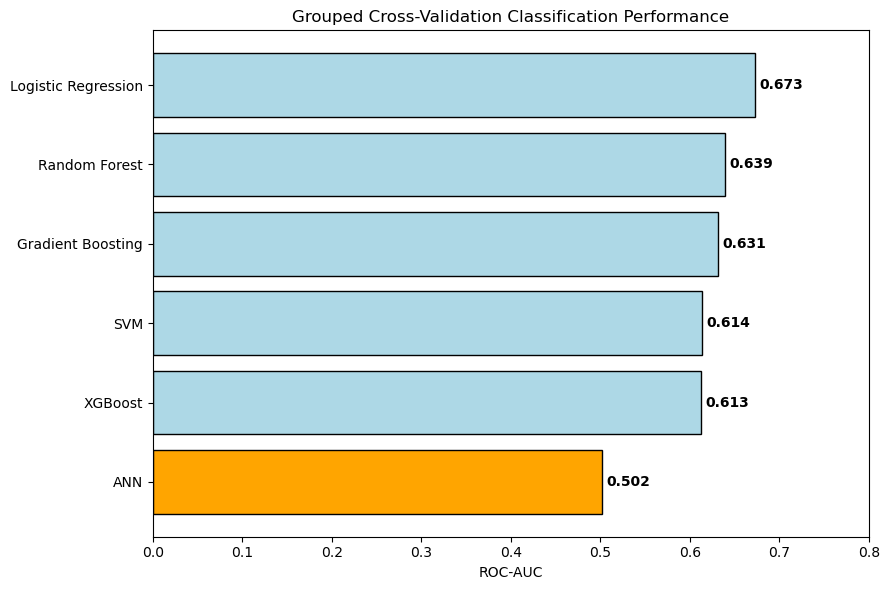

In [155]:
# ROC-AUC COMPARISON
plt.figure(figsize=(9,6))

plot_df = classification_summary.sort_values(
    "ROC_AUC"
)
colors = ["Orange"] + ["LightBlue"] * (len(plot_df)-1)
plt.barh(
    plot_df["Model"],
    plot_df["ROC_AUC"],    
    color=colors,
    edgecolor="black"
)
for i, value in enumerate(plot_df["ROC_AUC"]):
    plt.text(
        value + 0.005,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )
plt.xlabel("ROC-AUC")

plt.title(
    "Grouped Cross-Validation Classification Performance"
)
plt.xlim(0,0.8)
plt.tight_layout()

plt.show()

In [156]:
# CROSS-VALIDATED PREDICTIONS - LOGISTIC REGRESSION
from sklearn.model_selection import cross_val_predict

logistic_pipeline = classification_models["Logistic Regression"]

y_pred_logistic = cross_val_predict(
    estimator=logistic_pipeline,
    X=X_class,
    y=y_class,
    groups=groups_class,
    cv=group_cv_class,
    method="predict",
    n_jobs=1
)

y_prob_logistic = cross_val_predict(
    estimator=logistic_pipeline,
    X=X_class,
    y=y_class,
    groups=groups_class,
    cv=group_cv_class,
    method="predict_proba",
    n_jobs=1
)[:,1]

print("Predictions generated.")

Predictions generated.


### Confusion Matrix

The confusion matrix summarizes the model's ability to correctly classify high-risk and low-risk county-year observations.

The Logistic Regression model correctly identified 121 high-risk observations while misclassifying 95 high-risk observations as low risk. Although false positives were present, the model demonstrated moderate sensitivity and is appropriate for public health screening applications where identifying potential high-risk counties is prioritized.

<Figure size 600x600 with 0 Axes>

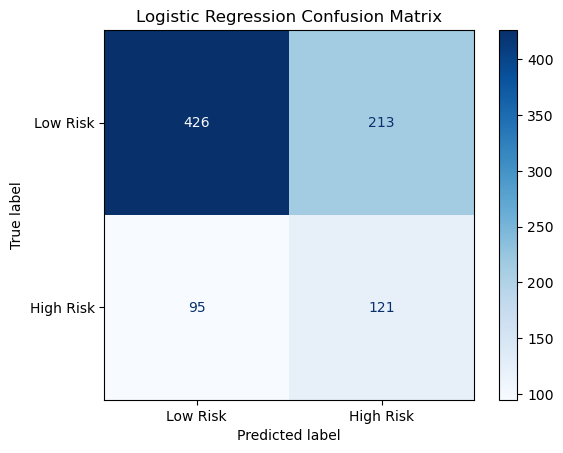

In [157]:
# Confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_class,
    y_pred_logistic
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Risk","High Risk"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Receiver Operating Characteristic (ROC) Curve

The ROC curve illustrates the trade-off between sensitivity and specificity across classification thresholds. The Logistic Regression model achieved an ROC-AUC of approximately 0.67, indicating moderate discrimination between high-risk and low-risk county-year observations.

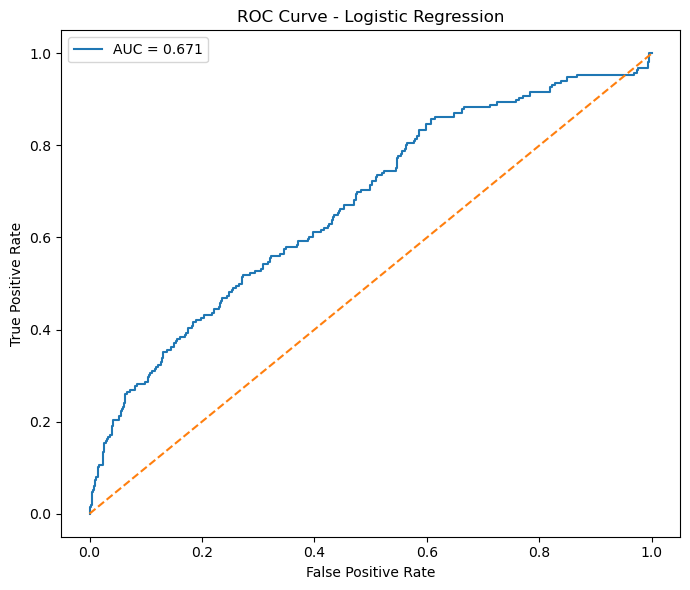

In [158]:
# ROC curve

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    y_class,
    y_prob_logistic
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.tight_layout()
plt.show()

### Precision–Recall Curve

Because only approximately 25% of observations were classified as high risk, the Precision–Recall curve provides additional insight into model performance under class imbalance.

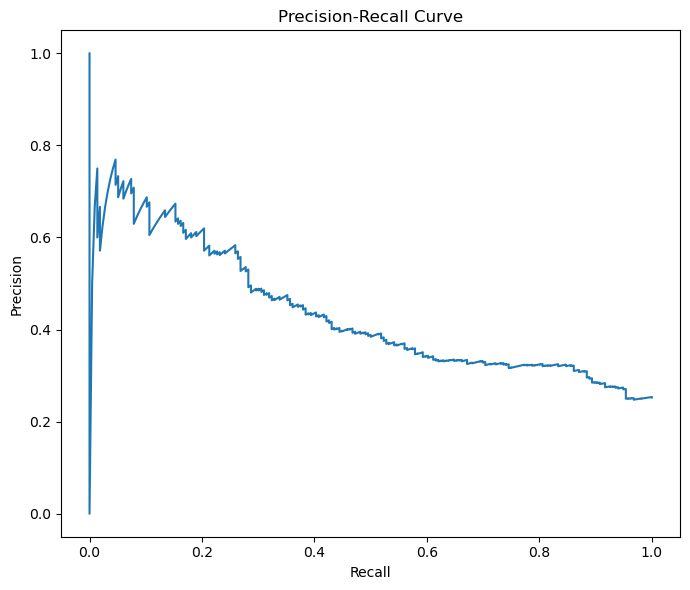

In [159]:
# PRECISION-RECALL CURVE

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_class,
    y_prob_logistic
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [160]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report

print(
    classification_report(
        y_class,
        y_pred_logistic,
        target_names=[
            "Low Risk",
            "High Risk"
        ]
    )
)

              precision    recall  f1-score   support

    Low Risk       0.82      0.67      0.73       639
   High Risk       0.36      0.56      0.44       216

    accuracy                           0.64       855
   macro avg       0.59      0.61      0.59       855
weighted avg       0.70      0.64      0.66       855



In [161]:
# FIT FINAL LOGISTIC REGRESSION MODEL
logistic_model = classification_models["Logistic Regression"]

logistic_model.fit(X_class, y_class)

print("Final Logistic Regression model fitted.")

Final Logistic Regression model fitted.


In [162]:
# GET SELECTED FEATURES
selector = logistic_model.named_steps["selector"]

selected_features = X_class.columns[selector.support_]

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['smoking_rate', 'early_prenatal_rate', 'medicaid_rate', 'low_education_rate', 'median_income', 'poverty_rate', 'bachelors_plus_rate', 'uninsured_rate', 'adult_obesity_rate', 'physical_inactivity_rate']


## Model Interpretation

Logistic Regression coefficients were examined to identify variables associated with increased or decreased odds of high-risk county classification.

Physical inactivity, Medicaid-covered births, adult obesity, and lower educational attainment showed positive associations with high-risk classification, whereas higher educational attainment and early prenatal care demonstrated protective associations after adjustment for other predictors.

In [163]:
# LOGISTIC REGRESSION COEFFICIENTS
coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coef_df = pd.DataFrame({

    "Variable": selected_features,
    "Coefficient": coefficients

})

coef_df["Odds_Ratio"] = np.exp(
    coef_df["Coefficient"]
)

coef_df = (
    coef_df
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    coef_df.round(3)
)

,Variable,Coefficient,Odds_Ratio
0,physical_inactivity_rate,0.677,1.967
1,medicaid_rate,0.409,1.505
2,adult_obesity_rate,0.249,1.283
3,low_education_rate,0.084,1.087
4,median_income,-0.028,0.972
5,smoking_rate,-0.041,0.960
6,early_prenatal_rate,-0.048,0.953
7,bachelors_plus_rate,-0.157,0.854
8,poverty_rate,-0.172,0.842
9,uninsured_rate,-0.646,0.524


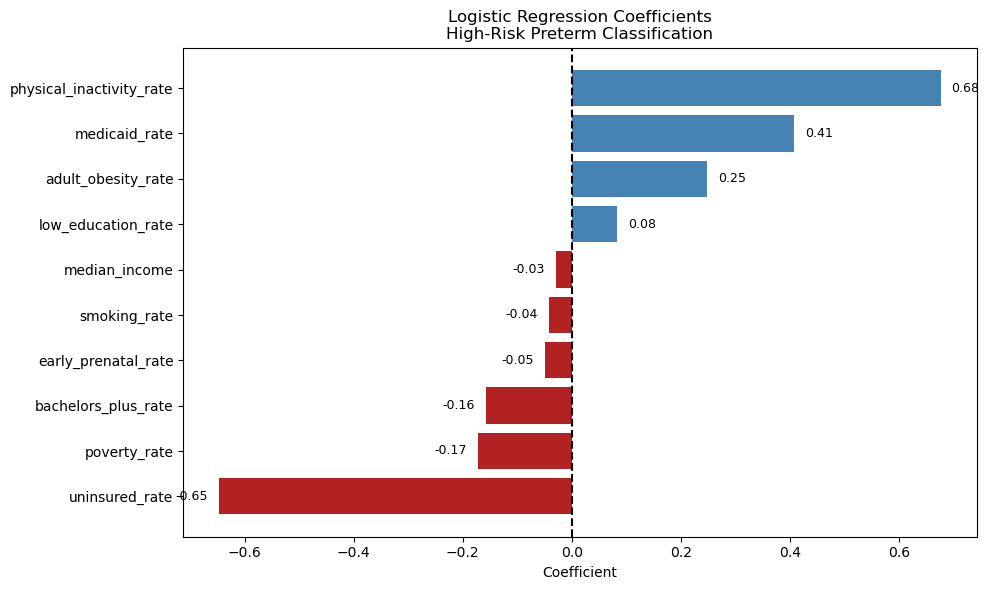

In [164]:
# PLOT LOGISTIC REGRESSION COEFFICIENTS


plot_df = coef_df.sort_values(
    "Coefficient"
)

plt.figure(figsize=(10,6))

colors = [
    "steelblue" if x > 0 else "firebrick"
    for x in plot_df["Coefficient"]
]

plt.barh(
    plot_df["Variable"],
    plot_df["Coefficient"],
    color=colors
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)
for i, value in enumerate(plot_df["Coefficient"]):
    plt.text(
        value + 0.02 if value > 0 else value - 0.08,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )
plt.title(
    "Logistic Regression Coefficients\nHigh-Risk Preterm Classification"
)

plt.xlabel("Coefficient")

plt.tight_layout()

plt.show()

In [165]:
# SAVE LOGISTIC REGRESSION COEFFICIENTS

coef_df.to_csv(
    OUTPUT_PATH / "logistic_regression_coefficients.csv",
    index=False
)

print("Coefficients saved.")

Coefficients saved.


### Random Forest Feature Importance

Random Forest feature importance complements the Logistic Regression coefficients by identifying predictors that contribute most strongly to model performance, regardless of the direction of association.

In [166]:
# RANDOM FOREST FEATURE IMPORTANCE


rf_pipeline = classification_models["Random Forest"]

rf_pipeline.fit(X_class, y_class)

selector = rf_pipeline.named_steps["selector"]

selected_features = X_class.columns[selector.support_]

importance = (
    rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

rf_importance = pd.DataFrame({
    "Variable": selected_features,
    "Importance": importance
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

display(rf_importance)

,Variable,Importance
2,medicaid_rate,0.138229
3,low_education_rate,0.129400
0,smoking_rate,0.124886
1,early_prenatal_rate,0.118457
6,bachelors_plus_rate,0.097189
8,adult_obesity_rate,0.083529
4,median_income,0.083031
9,physical_inactivity_rate,0.078426
5,poverty_rate,0.074677
7,uninsured_rate,0.072176


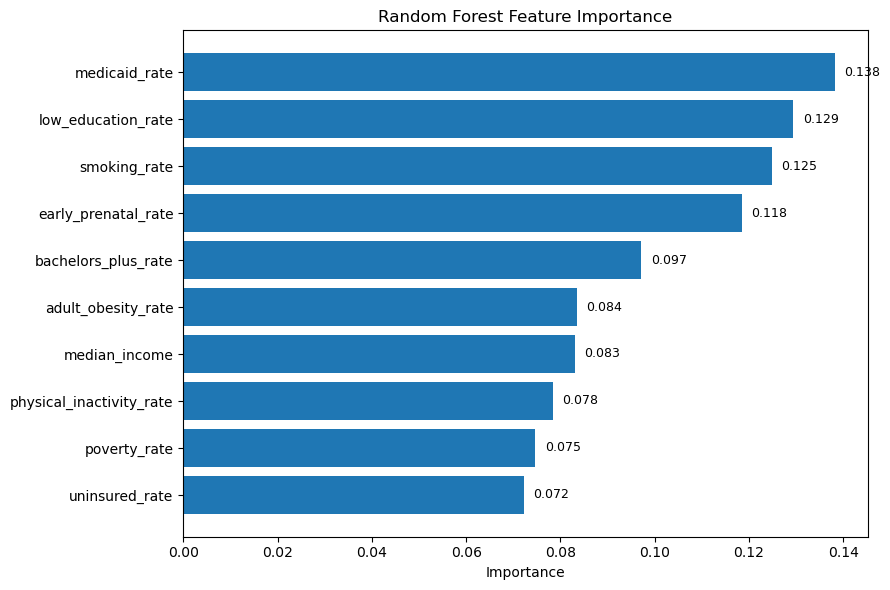

In [167]:
plt.figure(figsize=(9,6))

plot_df = rf_importance.sort_values("Importance")

plt.barh(
    plot_df["Variable"],
    plot_df["Importance"]
)
for i, value in enumerate(plot_df["Importance"]):
    plt.text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

# Discussion

The machine learning models identified several maternal health and county-level socioeconomic factors associated with adverse birth outcomes in Missouri. Model performance was evaluated using multiple metrics to compare predictive accuracy and determine the usefulness of county-level social determinants in predicting maternal health outcomes.

The findings demonstrate that integrating clinical, behavioral, socioeconomic, and healthcare access indicators provides valuable information for predicting county-level maternal health risks. These results may help inform targeted public health interventions and resource allocation.

# Limitations

Several limitations should be considered when interpreting these findings. First, this study used county-level aggregated data, which cannot capture individual-level risk factors or establish causal relationships. Second, differences in reporting practices across data sources may introduce measurement variability. Finally, although multiple datasets were integrated, some potentially important maternal characteristics were unavailable or suppressed within publicly available data.

Future work could incorporate individual-level electronic health records or longitudinal datasets to improve prediction accuracy and better understand maternal health disparities.

# Conclusion

This study developed machine learning models to predict maternal health risks and adverse birth outcomes in Missouri by integrating Missouri Birth MICA, American Community Survey, and County Health Rankings data.

The integrated dataset provided comprehensive information on maternal health indicators, socioeconomic conditions, and healthcare access across Missouri counties. Exploratory analyses identified meaningful relationships among predictors, while predictive models demonstrated the potential of machine learning approaches for identifying communities at elevated risk for adverse birth outcomes.

These findings support the use of data-driven approaches to improve maternal health surveillance and inform public health planning and intervention strategies.